# Data Analytics - Datathon Passos Mágicos

**Associação Passos Mágicos** · Pós Tech · Fase 5

---
# Parte 0 — Preparação do ambiente

In [1]:
import re
import unicodedata
import warnings
from pathlib import Path

import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import numpy as np
import pandas as pd
import seaborn as sns

warnings.filterwarnings("ignore")

pd.set_option("display.max_columns", 100)
pd.set_option("display.width", 220)
pd.set_option("display.float_format", lambda v: f"{v:,.3f}")

sns.set_theme(style="whitegrid")
plt.rcParams.update({
    "figure.dpi": 110,
    "axes.titlesize": 12,
    "axes.titleweight": "bold",
    "axes.labelsize": 10,
    "font.size": 10,
})

# paleta usada no notebook inteiro
COR = {
    "principal": "#2b6cb0",
    "apoio": "#63b3ed",
    "alerta": "#c53030",
    "atencao": "#dd6b20",
    "ok": "#2f855a",
    "neutro": "#718096",
}
PALETA_PEDRA = {
    "Quartzo": "#a0aec0",
    "Ágata": "#68a4c4",
    "Ametista": "#805ad5",
    "Topázio": "#d69e2e",
}
SEMENTE = 42

In [2]:
# o notebook fica na raiz do projeto e os CSVs em Arquivos_Base/
PASTA_BASE = Path.cwd() / "Arquivos_Base"

ARQUIVOS_ANO = {
    2022: "BASE DE DADOS PEDE 2022.csv",
    2023: "BASE DE DADOS PEDE 2023.csv",
    2024: "BASE DE DADOS PEDE 2024.csv",
}

ANOS = [2022, 2023, 2024]
INDICADORES = ["IAA", "IEG", "IPS", "IPP", "IDA", "IPV", "IAN"]
ORDEM_PEDRA = ["Quartzo", "Ágata", "Ametista", "Topázio"]

NOME_INDICADOR = {
    "IAA": "Autoavaliação",
    "IEG": "Engajamento",
    "IPS": "Psicossocial",
    "IPP": "Psicopedagógico",
    "IDA": "Aprendizagem",
    "IPV": "Ponto de Virada",
    "IAN": "Adequação ao Nível",
}

# se algum CSV estiver faltando, rode antes: python exportar_csv.py
faltando = [nome for nome in ARQUIVOS_ANO.values() if not (PASTA_BASE / nome).exists()]
if faltando:
    raise FileNotFoundError(f"Arquivos ausentes em {PASTA_BASE}: {faltando}")

print("Pasta de dados:", PASTA_BASE)
for arquivo in sorted(PASTA_BASE.glob("*.csv")):
    print(f"  {arquivo.name:38s} {arquivo.stat().st_size/1024:7.0f} KB")

Pasta de dados: /home/claude/nb2/Arquivos_Base
  BASE DE DADOS PEDE 2022.csv                378 KB
  BASE DE DADOS PEDE 2023.csv                236 KB
  BASE DE DADOS PEDE 2024.csv                341 KB


# Parte 1 — Entendimento dos dados

## 1.1 O que existe em cada arquivo

São três CSVs, um por ano (2022, 2023 e 2024), todos no formato *tidy*: uma linha por
aluno naquele ano. Os três compartilham o identificador `RA`, o que permite acompanhar o
mesmo aluno ao longo do tempo.

In [3]:
def ler_csv(nome_arquivo: str) -> pd.DataFrame:
    caminho = PASTA_BASE / nome_arquivo
    df = pd.read_csv(caminho, sep=";", encoding="utf-8-sig", dtype=str)
    return df.dropna(how="all").reset_index(drop=True)


brutos = {ano: ler_csv(arq) for ano, arq in ARQUIVOS_ANO.items()}

resumo = pd.DataFrame(
    [{"fonte": f"PEDE {ano}", "linhas": df.shape[0], "colunas": df.shape[1]}
     for ano, df in brutos.items()]
)
resumo

,fonte,linhas,colunas
0,PEDE 2022,860,42
1,PEDE 2023,1014,48
2,PEDE 2024,1156,50


In [4]:
for ano, df in brutos.items():
    print(f"PEDE {ano} ({df.shape[1]} colunas)")
    print(list(df.columns))
    print()

PEDE 2022 (42 colunas)
['RA', 'Fase', 'Turma', 'Nome', 'Ano nasc', 'Idade 22', 'Gênero', 'Ano ingresso', 'Instituição de ensino', 'Pedra 20', 'Pedra 21', 'Pedra 22', 'INDE 22', 'Cg', 'Cf', 'Ct', 'Nº Av', 'Avaliador1', 'Rec Av1', 'Avaliador2', 'Rec Av2', 'Avaliador3', 'Rec Av3', 'Avaliador4', 'Rec Av4', 'IAA', 'IEG', 'IPS', 'Rec Psicologia', 'IDA', 'Matem', 'Portug', 'Inglês', 'Indicado', 'Atingiu PV', 'IPV', 'IAN', 'Fase ideal', 'Defas', 'Destaque IEG', 'Destaque IDA', 'Destaque IPV']

PEDE 2023 (48 colunas)
['RA', 'Fase', 'INDE 2023', 'Pedra 2023', 'Turma', 'Nome Anonimizado', 'Data de Nasc', 'Idade', 'Gênero', 'Ano ingresso', 'Instituição de ensino', 'Pedra 20', 'Pedra 21', 'Pedra 22', 'Pedra 23', 'INDE 22', 'INDE 23', 'Cg', 'Cf', 'Ct', 'Nº Av', 'Avaliador1', 'Rec Av1', 'Avaliador2', 'Rec Av2', 'Avaliador3', 'Rec Av3', 'Avaliador4', 'Rec Av4', 'IAA', 'IEG', 'IPS', 'IPP', 'Rec Psicologia', 'IDA', 'Mat', 'Por', 'Ing', 'Indicado', 'Atingiu PV', 'IPV', 'IAN', 'Fase Ideal', 'Defasagem', '

Identificação dos padrões de preenchimento entre os arquivos

In [5]:
def comparar_nomes(conceitos: dict[str, list[str]]) -> pd.DataFrame:
    """Para cada conceito, mostra sob qual nome ele aparece em cada ano."""
    linhas = []
    for conceito, apelidos in conceitos.items():
        linha = {"conceito": conceito}
        for ano, df in brutos.items():
            achados = [c for c in df.columns if c in apelidos]
            linha[ano] = achados[0] if achados else "AUSENTE"
        linhas.append(linha)
    return pd.DataFrame(linhas).set_index("conceito")


comparar_nomes({
    "Identificador":   ["RA"],
    "Nome":            ["Nome", "Nome Anonimizado"],
    "INDE":            ["INDE 22", "INDE 2023", "INDE 2024"],
    "Pedra":           ["Pedra 22", "Pedra 2023", "Pedra 2024"],
    "Idade":           ["Idade 22", "Idade"],
    "Nascimento":      ["Ano nasc", "Data de Nasc"],
    "Nota Matemática": ["Matem", "Mat"],
    "Nota Português":  ["Portug", "Por"],
    "Nota Inglês":     ["Inglês", "Ing"],
    "Fase ideal":      ["Fase ideal", "Fase Ideal"],
    "Defasagem":       ["Defas", "Defasagem"],
    "Psicopedagógico": ["IPP"],
    "Escola":          ["Escola"],
})

,2022,2023,2024
conceito,,,
Identificador,RA,RA,RA
Nome,Nome,Nome Anonimizado,Nome Anonimizado
INDE,INDE 22,INDE 2023,INDE 2024
Pedra,Pedra 22,Pedra 2023,Pedra 2024
Idade,Idade 22,Idade,Idade
Nascimento,Ano nasc,Data de Nasc,Data de Nasc
Nota Matemática,Matem,Mat,Mat
Nota Português,Portug,Por,Por
Nota Inglês,Inglês,Ing,Ing


Observações encontradas:

- `IPP` não existe em 2022
- `Escola` só aparece em 2024, não dá para usar em série histórica

## 1.3 O identificador é estável entre os anos?

Antes de qualquer consolidação: o `RA` do mesmo aluno se mantém de um arquivo para o
outro? Se sim, existe um painel longitudinal — e é ele que viabiliza o modelo preditivo.

A função de conversão numérica também entra aqui, porque tudo é lido como texto.

In [6]:
def para_numero(serie: pd.Series) -> pd.Series:

    if pd.api.types.is_numeric_dtype(serie):
        return serie.astype("float64")

    texto = serie.astype("string").str.strip()
    texto = texto.str.replace(r"^#.*!$", "", regex=True)

    eh_percentual = texto.str.endswith("%", na=False)
    texto = texto.str.rstrip("%")

    # o ponto só é milhar quando há vírgula na mesma célula
    tem_virgula = texto.str.contains(",", na=False)
    texto = texto.mask(tem_virgula, texto.str.replace(".", "", regex=False))
    texto = texto.str.replace(",", ".", regex=False)

    numero = pd.to_numeric(texto, errors="coerce")
    return numero.mask(eh_percentual, numero / 100)

In [7]:
# o RA é a chave que liga os três anos
ras = {ano: set(df["RA"].dropna()) for ano, df in brutos.items()}

print("Alunos por ano:", {a: len(v) for a, v in ras.items()})
print()
print(f"2022 ∩ 2023      : {len(ras[2022] & ras[2023])}")
print(f"2023 ∩ 2024      : {len(ras[2023] & ras[2024])}")
print(f"2022 ∩ 2024      : {len(ras[2022] & ras[2024])}")
print(f"nos três anos    : {len(ras[2022] & ras[2023] & ras[2024])}")
print(f"alunos distintos : {len(ras[2022] | ras[2023] | ras[2024])}")

Alunos por ano: {2022: 860, 2023: 1014, 2024: 1156}

2022 ∩ 2023      : 600
2023 ∩ 2024      : 765
2022 ∩ 2024      : 472
nos três anos    : 468
alunos distintos : 1661


Existe um painel longitudinal real: 600 alunos observados em 2022 e 2023, 765 em 2023 e
2024, 468 nos três anos. É o que permite fazer o modelo preditivo — sem pares
`ano t → ano t+1` não há como prever nada.

## 1.4 Nulos: colunas e linhas

In [8]:
def perfil_nulos(df: pd.DataFrame, rotulo: str) -> pd.DataFrame:
    """% de preenchimento de cada coluna."""
    preenchido = df.notna().mean().mul(100).round(1)
    return (
        preenchido.rename(rotulo)
        .to_frame()
        .assign(coluna=preenchido.index)
        .reset_index(drop=True)[["coluna", rotulo]]
    )


for ano, df in brutos.items():
    vazias = [c for c in df.columns if df[c].notna().sum() == 0]
    parciais = {c: f"{df[c].notna().mean():.0%}"
                for c in df.columns if 0 < df[c].notna().mean() < 0.95}
    print(f"=== PEDE {ano}")
    print(f"  linhas totalmente vazias : {int(df.isna().all(axis=1).sum())}")
    print(f"  colunas 100% vazias ({len(vazias)}): {vazias}")
    print(f"  colunas entre 1% e 95%   : {parciais}")
    print()

=== PEDE 2022
  linhas totalmente vazias : 0
  colunas 100% vazias (0): []
  colunas entre 1% e 95%   : {'Pedra 20': '38%', 'Pedra 21': '54%', 'Avaliador3': '62%', 'Avaliador4': '36%', 'Rec Av4': '34%', 'Inglês': '33%'}

=== PEDE 2023
  linhas totalmente vazias : 0
  colunas 100% vazias (16): ['Pedra 23', 'INDE 23', 'Cg', 'Cf', 'Ct', 'Rec Av1', 'Rec Av2', 'Rec Av3', 'Rec Av4', 'Rec Psicologia', 'Indicado', 'Atingiu PV', 'Destaque IEG', 'Destaque IDA', 'Destaque IPV', 'Destaque IPV.1']
  colunas entre 1% e 95%   : {'INDE 2023': '92%', 'Pedra 2023': '92%', 'Pedra 20': '24%', 'Pedra 21': '33%', 'Pedra 22': '59%', 'INDE 22': '59%', 'Nº Av': '93%', 'Avaliador1': '93%', 'Avaliador2': '93%', 'Avaliador3': '70%', 'Avaliador4': '33%', 'IAA': '94%', 'IEG': '93%', 'IPS': '93%', 'IPP': '93%', 'IDA': '92%', 'Mat': '92%', 'Por': '92%', 'Ing': '33%', 'IPV': '93%'}



=== PEDE 2024
  linhas totalmente vazias : 0
  colunas 100% vazias (11): ['Cg', 'Cf', 'Ct', 'Rec Av1', 'Rec Av2', 'Rec Psicologia', 'Indicado', 'Atingiu PV', 'Destaque IEG', 'Destaque IDA', 'Destaque IPV']
  colunas entre 1% e 95%   : {'INDE 2024': '94%', 'Pedra 2024': '94%', 'Pedra 20': '17%', 'Pedra 21': '23%', 'Pedra 22': '41%', 'Pedra 23': '60%', 'INDE 22': '41%', 'INDE 23': '60%', 'Avaliador1': '89%', 'Avaliador2': '89%', 'Avaliador3': '69%', 'Avaliador4': '35%', 'Avaliador5': '13%', 'Avaliador6': '1%', 'IAA': '91%', 'IPS': '91%', 'IPP': '91%', 'IDA': '91%', 'Mat': '91%', 'Por': '91%', 'Ing': '41%', 'IPV': '91%'}



> ### Conclusão 1 — o Ponto de Virada não pode ser o alvo do modelo
>
> `Atingiu PV`, `Indicado`, `Rec Psicologia` e os campos `Destaque *` estão **100% vazios
> em 2023 e 2024**. Só existem preenchidos em 2022.
>
> Isso elimina "atingir o Ponto de Virada" como variável-resposta: não haveria rótulo nos
> anos recentes para treinar nem para validar. O alvo terá que ser construído a partir da
> **defasagem**, que está completa nos três anos — e é exatamente o que a pergunta 9 do
> enunciado pede.
>
> Também significa que a pergunta 7 (o que influencia o IPV) precisa ser respondida pelo
> **indicador numérico `IPV`**, não pelo booleano.

In [9]:
# preenchimento dos indicadores, que são o coração da análise
cobertura = pd.DataFrame({
    ano: {
        col: brutos[ano][col].notna().mean() * 100 if col in brutos[ano].columns else np.nan
        for col in INDICADORES
    }
    for ano in ANOS
})
cobertura.loc["INDE"] = [
    brutos[a][c].notna().mean() * 100
    for a, c in zip(ANOS, ["INDE 22", "INDE 2023", "INDE 2024"])
]
cobertura.round(1)

,2022,2023,2024
IAA,100.000,93.800,91.200
IEG,100.000,92.500,100.000
IPS,100.000,93.200,91.200
IPP,NaN,92.500,91.200
IDA,100.000,92.400,91.300
IPV,100.000,92.500,91.200
IAN,100.000,100.000,100.000
INDE,100.000,91.800,94.500


`IAN` é o único indicador com 100% de cobertura nos três anos — mais um argumento a
favor de ancorar o alvo do modelo na defasagem. Os demais faltam para 7% a 9% dos alunos
de 2023/2024, tipicamente quem entrou no meio do ciclo.

## 1.5 Armadilhas de leitura

Quatro problemas que passariam despercebidos e contaminariam a análise inteira.

In [10]:
# ARMADILHA 1 — em 2023 parte das idades foi gravada como data
idade_2023 = brutos[2023]["Idade"]
parece_data = idade_2023.str.contains("1900", na=False)

print(f"Valores de 'Idade' que viraram data em 2023: {parece_data.sum()} de {len(idade_2023)}")
print("Exemplos:", idade_2023[parece_data].unique()[:6].tolist())
print("Normais :", idade_2023[~parece_data].dropna().unique()[:6].tolist())
print()
print("O Excel leu o número 8 como '8 de janeiro de 1900'. O dia é a idade real.")

Valores de 'Idade' que viraram data em 2023: 399 de 1014
Exemplos: ['1900-01-08 00:00:00', '1900-01-07 00:00:00', '1900-01-11 00:00:00', '1900-01-09 00:00:00', '1900-01-10 00:00:00', '1900-01-14 00:00:00']
Normais : ['8', '9', '7', '10', '12', '11']

O Excel leu o número 8 como '8 de janeiro de 1900'. O dia é a idade real.


In [11]:
# ARMADILHA 2 — a coluna Fase muda de significado a cada ano
for ano in ANOS:
    valores = sorted(brutos[ano]["Fase"].dropna().unique())
    print(f"{ano} ({len(valores):2d} valores distintos): {valores[:14]}")

2022 ( 8 valores distintos): ['0', '1', '2', '3', '4', '5', '6', '7']
2023 ( 9 valores distintos): ['ALFA', 'FASE 1', 'FASE 2', 'FASE 3', 'FASE 4', 'FASE 5', 'FASE 6', 'FASE 7', 'FASE 8']
2024 (72 valores distintos): ['1A', '1B', '1C', '1D', '1E', '1G', '1H', '1J', '1K', '1L', '1M', '1N', '1P', '1R']


Em 2022 `Fase` é um número puro, em 2023 vem como texto (`ALFA`, `FASE 1`) e em 2024
ela **mistura fase e turma** (`1A`, `2B`). Comparar as três direto produziria 72
categorias sem sentido.

In [12]:
# ARMADILHA 3 — categorias escritas de formas diferentes
for coluna in ["Gênero", "Instituição de ensino"]:
    print(f"--- {coluna}")
    for ano in ANOS:
        print(f"  {ano}: {sorted(brutos[ano][coluna].dropna().unique())}")
    print()

print("--- Pedra")
for ano, col in zip(ANOS, ["Pedra 22", "Pedra 2023", "Pedra 2024"]):
    print(f"  {ano}: {sorted(brutos[ano][col].dropna().unique())}")

--- Gênero
  2022: ['Menina', 'Menino']
  2023: ['Feminino', 'Masculino']
  2024: ['Feminino', 'Masculino']

--- Instituição de ensino
  2022: ['Escola JP II', 'Escola Pública', 'Rede Decisão']
  2023: ['Concluiu o 3º EM', 'Nenhuma das opções acima', 'Privada', 'Privada *Parcerias com Bolsa 100%', 'Privada - Pagamento por *Empresa Parceira', 'Privada - Programa de Apadrinhamento', 'Privada - Programa de apadrinhamento', 'Pública']
  2024: ['Bolsista Universitário *Formado (a)', 'Concluiu o 3º EM', 'Privada', 'Privada *Parcerias com Bolsa 100%', 'Privada - Pagamento por *Empresa Parceira', 'Privada - Programa de Apadrinhamento', 'Privada - Programa de apadrinhamento', 'Pública']

--- Pedra
  2022: ['Ametista', 'Quartzo', 'Topázio', 'Ágata']
  2023: ['Agata', 'Ametista', 'Quartzo', 'Topázio']
  2024: ['Agata', 'Ametista', 'INCLUIR', 'Quartzo', 'Topázio']


`Ágata` perde o acento a partir de 2023 e aparece um valor de controle `INCLUIR` em
2024. Sem tratamento, `Ágata` e `Agata` viram duas categorias e ~470 alunos somem de
qualquer contagem por pedra.

In [13]:
# ARMADILHA 4 — todo número chega como texto, com vírgula decimal
amostra = brutos[2023]["IPS"]
print("Exemplos de IPS em 2023:", amostra.dropna().unique()[:6].tolist())
print("Depois da conversão    :", para_numero(amostra).dropna().unique()[:6].tolist())
print()

# colunas duplicadas na planilha ganham sufixo .1 na leitura
duplicadas = {ano: [c for c in df.columns if c.endswith(".1")] for ano, df in brutos.items()}
print("Colunas duplicadas na origem:", {a: v for a, v in duplicadas.items() if v})

Exemplos de IPS em 2023: ['8,13', '8,14', '3,14', '7,52', '8,76', '3,76']
Depois da conversão    : [8.13, 8.14, 3.14, 7.52, 8.76, 3.76]

Colunas duplicadas na origem: {2023: ['Destaque IPV.1'], 2024: ['Ativo/ Inativo.1']}


Todo valor numérico chega como texto com vírgula decimal — sem conversão, qualquer média
sai errada ou vira nulo.

O conversor também trata separador de milhar, células formatadas como porcentagem e erros
de fórmula (`#NULO!`). Esses casos **não aparecem nos CSVs atuais** porque eles são
gerados por script a partir do valor real da planilha; apareciam quando a exportação era
feita pelo "Salvar como CSV" do Excel, que grava o valor exibido. O tratamento fica no
código como proteção caso alguém reexporte pela planilha.

Aparecem ainda duas colunas duplicadas na origem (`Destaque IPV` em 2023 e
`Ativo/ Inativo` em 2024), que o pandas desambigua com sufixo `.1`. Como nenhuma das duas
entra no painel, basta registrar.

### Resumo do que a camada de padronização precisa fazer

| Problema | Tratamento |
|---|---|
| Nomes de coluna diferentes por ano | mapa explícito coluna → conceito |
| `Fase` como número / texto / fase+turma | extrair o número; `ALFA` = 0 |
| Idade gravada como data | usar o componente de dia |
| `Ágata`/`Agata`, `INCLUIR` | normalizar acentos e descartar controle |
| Vírgula decimal, milhar, `%`, `#NULO!` | conversor numérico tolerante |
| `Menina`/`Feminino`, `Escola Pública`/`Pública` | dicionário de equivalência |


---
# Parte 2 — Consolidação em um painel único

## 2.1 Formato alvo

O painel tem granularidade **`aluno × ano`**: cada linha é um aluno em um ano, com
colunas de nome fixo. Esse formato é o que permite comparar anos, calcular variações e
montar os pares `t → t+1` do modelo.

In [14]:
def sem_acento(texto: str) -> str:
    return "".join(
        c for c in unicodedata.normalize("NFKD", texto) if not unicodedata.combining(c)
    )


def normalizar_texto(serie: pd.Series) -> pd.Series:
    """Maiúsculas, sem acento e sem espaços nas pontas — para comparar categorias."""
    return (
        serie.astype("string").str.strip().str.upper()
        .map(sem_acento, na_action="ignore")
    )


def fase_para_numero(serie: pd.Series) -> pd.Series:
    """'ALFA' -> 0 | 'FASE 3' -> 3 | '3B' -> 3 | '7' -> 7"""
    texto = normalizar_texto(serie)
    numero = pd.Series(np.nan, index=serie.index, dtype="float64")
    numero = numero.mask(texto.str.startswith("ALFA", na=False), 0.0)
    return numero.fillna(pd.to_numeric(texto.str.extract(r"(\d+)")[0], errors="coerce"))


def fase_ideal_para_numero(serie: pd.Series) -> pd.Series:
    """'ALFA (1º e 2º ano)' -> 0 | 'Fase 5 (1º EM)' -> 5"""
    texto = normalizar_texto(serie)
    numero = pd.Series(np.nan, index=serie.index, dtype="float64")
    numero = numero.mask(texto.str.startswith("ALFA", na=False), 0.0)
    extraido = texto.str.extract(r"FASE\s*(\d+)")[0]
    return numero.fillna(pd.to_numeric(extraido, errors="coerce"))


def para_booleano(serie: pd.Series) -> pd.Series:
    return normalizar_texto(serie).map({"SIM": True, "NAO": False}).astype("boolean")


MAPA_GENERO = {"MENINA": "F", "FEMININO": "F", "MENINO": "M", "MASCULINO": "M"}

MAPA_INSTITUICAO = {
    "ESCOLA PUBLICA": "Pública",
    "PUBLICA": "Pública",
    "PRIVADA": "Privada",
    "REDE DECISAO": "Privada - Parceira",
    "ESCOLA JP II": "Privada - Parceira",
    "PRIVADA - PROGRAMA DE APADRINHAMENTO": "Privada - Apadrinhamento",
    "PRIVADA *PARCERIAS COM BOLSA 100%": "Privada - Bolsa 100%",
    "PRIVADA - PAGAMENTO POR *EMPRESA PARCEIRA": "Privada - Empresa parceira",
    "CONCLUIU O 3º EM": "Concluiu o 3º EM",
    "CONCLUIU O 3O EM": "Concluiu o 3º EM",
    "NENHUMA DAS OPCOES ACIMA": "Nenhuma",
}

MAPA_PEDRA = {
    "QUARTZO": "Quartzo", "AGATA": "Ágata",
    "AMETISTA": "Ametista", "TOPAZIO": "Topázio",
}


def padronizar_pedra(serie: pd.Series) -> pd.Categorical:
    """Resolve 'Agata' sem acento e descarta o valor de controle 'INCLUIR'."""
    return pd.Categorical(
        normalizar_texto(serie).map(MAPA_PEDRA),
        categories=ORDEM_PEDRA, ordered=True,
    )


def corrigir_idade(serie: pd.Series) -> pd.Series:
    """Idades gravadas como '1900-01-08' voltam a ser 8 (o dia é a idade)."""
    texto = serie.astype("string").str.strip()
    numero = pd.to_numeric(texto, errors="coerce")

    eh_data_1900 = texto.str.match(r"1900-\d{2}-\d{2}").fillna(False)
    dia = pd.to_numeric(texto.str.extract(r"^1900-\d{2}-(\d{2})")[0], errors="coerce")
    return numero.mask(eh_data_1900, dia).astype("float64")


def extrair_ano_nascimento(serie: pd.Series) -> pd.Series:
    """
    Só o ANO. A coluna mistura '6/17/2015' (mês/dia/ano digitado à mão) com
    '2015-12-03' (formatado pelo Excel) — o ano é a única parte confiável em ambos.
    """
    texto = serie.astype("string").str.strip()
    ano_iso = texto.str.extract(r"^(\d{4})-")[0]
    ano_final = texto.str.extract(r"(\d{4})\s*$")[0]
    return pd.to_numeric(ano_iso.fillna(ano_final), errors="coerce").astype("float64")


print("Funções de padronização definidas.")

Funções de padronização definidas.


## 2.2 Mapa de colunas

Cada ano declara explicitamente de onde vem cada conceito. Conceitos ausentes naquele ano
(por exemplo `IPP` em 2022) simplesmente não aparecem no mapa e viram nulo.

In [15]:
MAPA_COLUNAS = {
    2022: {
        "id_aluno": "RA", "nome": "Nome", "fase_bruta": "Fase", "turma": "Turma",
        "ano_nascimento_bruto": "Ano nasc", "idade": "Idade 22", "genero": "Gênero",
        "ano_ingresso": "Ano ingresso", "instituicao": "Instituição de ensino",
        "inde": "INDE 22", "pedra": "Pedra 22",
        "rank_geral": "Cg", "rank_fase": "Cf", "rank_turma": "Ct",
        "qtd_avaliadores": "Nº Av",
        "IAA": "IAA", "IEG": "IEG", "IPS": "IPS", "IDA": "IDA",
        "IPV": "IPV", "IAN": "IAN",
        "nota_mat": "Matem", "nota_por": "Portug", "nota_ing": "Inglês",
        "atingiu_pv": "Atingiu PV", "indicado_bolsa": "Indicado",
        "fase_ideal_bruta": "Fase ideal", "defasagem_original": "Defas",
    },
    2023: {
        "id_aluno": "RA", "nome": "Nome Anonimizado", "fase_bruta": "Fase",
        "turma": "Turma", "data_nascimento": "Data de Nasc", "idade": "Idade",
        "genero": "Gênero", "ano_ingresso": "Ano ingresso",
        "instituicao": "Instituição de ensino",
        "inde": "INDE 2023", "pedra": "Pedra 2023",
        "rank_geral": "Cg", "rank_fase": "Cf", "rank_turma": "Ct",
        "qtd_avaliadores": "Nº Av",
        "IAA": "IAA", "IEG": "IEG", "IPS": "IPS", "IPP": "IPP", "IDA": "IDA",
        "IPV": "IPV", "IAN": "IAN",
        "nota_mat": "Mat", "nota_por": "Por", "nota_ing": "Ing",
        "atingiu_pv": "Atingiu PV", "indicado_bolsa": "Indicado",
        "fase_ideal_bruta": "Fase Ideal", "defasagem_original": "Defasagem",
    },
    2024: {
        "id_aluno": "RA", "nome": "Nome Anonimizado", "fase_bruta": "Fase",
        "turma": "Turma", "data_nascimento": "Data de Nasc", "idade": "Idade",
        "genero": "Gênero", "ano_ingresso": "Ano ingresso",
        "instituicao": "Instituição de ensino", "escola": "Escola",
        "inde": "INDE 2024", "pedra": "Pedra 2024",
        "rank_geral": "Cg", "rank_fase": "Cf", "rank_turma": "Ct",
        "qtd_avaliadores": "Nº Av",
        "IAA": "IAA", "IEG": "IEG", "IPS": "IPS", "IPP": "IPP", "IDA": "IDA",
        "IPV": "IPV", "IAN": "IAN",
        "nota_mat": "Mat", "nota_por": "Por", "nota_ing": "Ing",
        "atingiu_pv": "Atingiu PV", "indicado_bolsa": "Indicado",
        "fase_ideal_bruta": "Fase Ideal", "defasagem_original": "Defasagem",
    },
}

COLUNAS_NUMERICAS = [
    "inde", "rank_geral", "rank_fase", "rank_turma", "qtd_avaliadores",
    "nota_mat", "nota_por", "nota_ing", "ano_ingresso", *INDICADORES,
]

ROTULO_DEFASAGEM = ["Severa (3+)", "Alta (2)", "Moderada (1)", "Adequado", "Adiantado"]

In [16]:
def padronizar_ano(ano: int) -> pd.DataFrame:
    """Aplica o mapa de colunas e todas as padronizações a um ano."""
    bruto = brutos[ano]
    mapa = MAPA_COLUNAS[ano]

    df = pd.DataFrame(index=bruto.index)
    df["ano"] = ano
    for canonico, original in mapa.items():
        df[canonico] = bruto[original] if original in bruto.columns else pd.NA

    # garante que todo indicador exista, mesmo ausente naquele ano
    for indicador in INDICADORES:
        if indicador not in df.columns:
            df[indicador] = np.nan

    df["id_aluno"] = df["id_aluno"].astype("string").str.strip()
    df["nome"] = df["nome"].astype("string").str.strip()
    df["turma"] = df["turma"].astype("string").str.strip()

    for coluna in COLUNAS_NUMERICAS:
        df[coluna] = para_numero(df[coluna])

    df["fase"] = fase_para_numero(df["fase_bruta"])
    df["fase_ideal"] = fase_ideal_para_numero(df["fase_ideal_bruta"])
    df["defasagem_original"] = para_numero(df["defasagem_original"])
    df["pedra"] = padronizar_pedra(df["pedra"])
    df["genero"] = normalizar_texto(df["genero"]).map(MAPA_GENERO).astype("string")

    instituicao = normalizar_texto(df["instituicao"])
    df["instituicao"] = (
        instituicao.map(MAPA_INSTITUICAO)
        .fillna(df["instituicao"].astype("string").str.strip())
        .astype("string")
    )

    df["idade"] = corrigir_idade(df["idade"])
    if "data_nascimento" in df.columns:
        df["ano_nascimento"] = extrair_ano_nascimento(df["data_nascimento"])
    else:
        df["ano_nascimento"] = para_numero(df["ano_nascimento_bruto"])
    df["idade"] = df["idade"].fillna(ano - df["ano_nascimento"])

    for coluna in ("atingiu_pv", "indicado_bolsa"):
        df[coluna] = para_booleano(df[coluna])

    # derivadas
    df["defasagem"] = df["fase"] - df["fase_ideal"]
    df["defasado"] = df["defasagem"] < 0
    df["nivel_defasagem"] = pd.Categorical(
        pd.cut(df["defasagem"], bins=[-np.inf, -2.5, -1.5, -0.5, 0.5, np.inf],
               labels=ROTULO_DEFASAGEM),
        categories=ROTULO_DEFASAGEM, ordered=True,
    )

    return df.drop(columns=[
        "fase_bruta", "fase_ideal_bruta", "data_nascimento", "ano_nascimento_bruto",
    ], errors="ignore")


ORDEM_FINAL = [
    "id_aluno", "ano", "nome", "genero", "idade", "ano_nascimento",
    "ano_ingresso", "anos_na_pm", "instituicao", "escola", "turma",
    "fase", "fase_ideal", "defasagem", "defasado", "nivel_defasagem",
    "inde", "pedra", *INDICADORES,
    "nota_mat", "nota_por", "nota_ing", "qtd_avaliadores",
    "rank_geral", "rank_fase", "rank_turma",
    "atingiu_pv", "indicado_bolsa", "defasagem_original",
]


def construir_painel() -> pd.DataFrame:
    painel = pd.concat([padronizar_ano(a) for a in ANOS], ignore_index=True, sort=False)

    # 'Ano ingresso' diverge entre anos para o mesmo aluno; adotamos o menor
    painel["ano_ingresso_declarado"] = painel["ano_ingresso"]
    painel["ano_ingresso"] = painel.groupby("id_aluno")["ano_ingresso"].transform("min")
    painel["ingresso_inconsistente"] = (
        painel.groupby("id_aluno")["ano_ingresso_declarado"].transform("nunique") > 1
    )
    painel["anos_na_pm"] = painel["ano"] - painel["ano_ingresso"]
    painel["n_anos_observados"] = painel.groupby("id_aluno")["ano"].transform("size")

    colunas = [c for c in ORDEM_FINAL if c in painel.columns]
    restantes = [c for c in painel.columns if c not in colunas]
    return (
        painel[colunas + restantes]
        .sort_values(["id_aluno", "ano"])
        .reset_index(drop=True)
    )


painel = construir_painel()
print("Painel:", painel.shape)
painel.head(6)

Painel: (3030, 38)


,id_aluno,ano,nome,genero,idade,ano_nascimento,ano_ingresso,anos_na_pm,instituicao,escola,turma,fase,fase_ideal,defasagem,defasado,nivel_defasagem,inde,pedra,IAA,IEG,IPS,IPP,IDA,IPV,IAN,nota_mat,nota_por,nota_ing,qtd_avaliadores,rank_geral,rank_fase,rank_turma,atingiu_pv,indicado_bolsa,defasagem_original,ano_ingresso_declarado,ingresso_inconsistente,n_anos_observados
0,RA-1,2022,Aluno-1,F,19.000,"2,003.000",2016,6,Pública,NaN,A,7.000,8.000,-1.000,True,Moderada (1),5.783,Quartzo,8.300,4.100,5.600,<NA>,4.000,7.278,5.000,2.700,3.500,6.000,4.000,753.000,18.000,10.000,False,True,-1,2016,True,3
1,RA-1,2023,Aluno-1,F,20.000,"2,003.000",2016,7,Privada - Bolsa 100%,NaN,8E,8.000,8.000,0.000,False,Adequado,<NA>,NaN,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,10.000,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,0,2016,True,3
2,RA-1,2024,Aluno-1,F,21.000,"2,003.000",2016,8,Privada - Bolsa 100%,Universidade Santo Amaro (UNISA),8E,8.000,8.000,0.000,False,Adequado,<NA>,NaN,<NA>,0.000,<NA>,<NA>,<NA>,<NA>,10.000,<NA>,<NA>,<NA>,0.000,<NA>,<NA>,<NA>,<NA>,<NA>,0,2021,True,3
3,RA-10,2022,Aluno-10,F,18.000,"2,004.000",2021,1,Pública,NaN,A,7.000,8.000,-1.000,True,Moderada (1),5.784,Quartzo,8.300,5.200,5.000,<NA>,4.100,7.056,5.000,3.300,2.600,6.400,4.000,752.000,17.000,9.000,False,False,-1,2021,False,1
4,RA-100,2022,Aluno-100,F,13.000,"2,009.000",2019,3,Privada - Parceira,NaN,A,4.000,3.000,1.000,False,Adiantado,7.618,Ametista,8.800,7.800,5.000,<NA>,7.600,7.250,10.000,7.000,7.800,8.100,4.000,268.000,22.000,7.000,False,False,1,2019,False,1
5,RA-1000,2023,Aluno-1000,F,8.000,"2,015.000",2023,0,Pública,NaN,ALFA U - G2/G3,0.000,0.000,0.000,False,Adequado,7.916,Ametista,8.500,9.400,3.770,6.250,7.000,8.920,10.000,7.000,7.000,<NA>,2.000,<NA>,<NA>,<NA>,<NA>,<NA>,0,2023,False,2


In [17]:
painel.info()

<class 'pandas.DataFrame'>
RangeIndex: 3030 entries, 0 to 3029
Data columns (total 38 columns):
 #   Column                  Non-Null Count  Dtype   
---  ------                  --------------  -----   
 0   id_aluno                3030 non-null   string  
 1   ano                     3030 non-null   int64   
 2   nome                    3030 non-null   string  
 3   genero                  3030 non-null   string  
 4   idade                   3030 non-null   float64 
 5   ano_nascimento          3030 non-null   Float64 
 6   ano_ingresso            3030 non-null   Int64   
 7   anos_na_pm              3030 non-null   Int64   
 8   instituicao             3029 non-null   string  
 9   escola                  1155 non-null   str     
 10  turma                   3030 non-null   string  
 11  fase                    3030 non-null   float64 
 12  fase_ideal              3030 non-null   float64 
 13  defasagem               3030 non-null   float64 
 14  defasado                3030 non-nu

## 2.3 Validações

Cinco checagens antes de confiar no painel.

In [18]:
# V1 — a chave aluno × ano é única?
duplicadas = painel.duplicated(["id_aluno", "ano"]).sum()
print(f"V1  duplicidades aluno×ano: {duplicadas}")

# V2 — a defasagem recalculada bate com a que veio na planilha?
comparavel = painel.dropna(subset=["defasagem", "defasagem_original"])
iguais = (comparavel["defasagem"] == comparavel["defasagem_original"])
print(f"V2  defasagem recalculada == original: {iguais.mean():.2%} de {len(comparavel)} linhas")
display(comparavel.loc[~iguais, ["id_aluno", "ano", "fase", "fase_ideal",
                                 "defasagem", "defasagem_original"]])

V1  duplicidades aluno×ano: 0
V2  defasagem recalculada == original: 99.93% de 3030 linhas


,id_aluno,ano,fase,fase_ideal,defasagem,defasagem_original
831,RA-1516,2024,3.000,3.000,0.000,3
834,RA-1519,2024,3.000,3.000,0.000,3


In [19]:
# V3 — a Pedra corresponde às faixas de INDE do dicionário de dados?
FAIXAS_DICIONARIO = {
    "Quartzo": (2.405, 5.506), "Ágata": (5.506, 6.868),
    "Ametista": (6.868, 8.230), "Topázio": (8.230, 9.294),
}

def classificar(valor, faixas):
    if pd.isna(valor):
        return None
    for pedra, (minimo, maximo) in faixas.items():
        if minimo <= valor <= maximo:
            return pedra
    return "fora das faixas"

conferencia = painel.dropna(subset=["inde", "pedra"]).copy()
conferencia["pelo_dicionario"] = conferencia["inde"].map(
    lambda v: classificar(v, FAIXAS_DICIONARIO)
)
print("V3  Pedra informada × faixa do dicionário:")
display(pd.crosstab(conferencia["pedra"], conferencia["pelo_dicionario"]))

print("Limites de INDE observados em cada pedra:")
display(
    conferencia.groupby(["ano", "pedra"], observed=True)["inde"]
    .agg(["min", "max", "size"]).round(3)
)

V3  Pedra informada × faixa do dicionário:


pelo_dicionario,Ametista,Quartzo,Topázio,fora das faixas,Ágata
pedra,,,,,
Quartzo,0,149,0,0,167
Ágata,128,0,0,0,593
Ametista,1120,0,0,0,0
Topázio,219,0,457,12,0


Limites de INDE observados em cada pedra:


min   max  size
ano  pedra                     
2022 Quartzo  3.032 5.989   132
     Ágata    6.011 7.028   250
     Ametista 7.035 8.058   348
     Topázio  8.060 9.442   130
2023 Quartzo  3.746 5.996    72
     Ágata    6.009 6.994   246
     Ametista 7.000 7.997   381
     Topázio  8.003 9.371   232
2024 Quartzo  3.789 5.984   112
     Ágata    6.015 7.000   225
     Ametista 7.003 7.994   391
     Topázio  8.003 9.531   326

> ### Conclusão 2 — o dicionário de dados está desatualizado
>
> A Pedra informada **não** segue as faixas do dicionário. Os cortes efetivos em
> 2022–2024 são redondos: Quartzo `< 6`, Ágata `[6, 7)`, Ametista `[7, 8)`,
> Topázio `>= 8`. O dicionário descreve o ciclo antigo (2020–2022).
>
> Nunca reclassificar alunos pelas faixas do dicionário — e vale registrar isso como
> recomendação de governança de dados para a Passos Mágicos.

In [20]:
# V4 — o ano de ingresso é consistente para o mesmo aluno?
inconsistentes = painel.drop_duplicates("id_aluno")["ingresso_inconsistente"].sum()
total_alunos = painel["id_aluno"].nunique()
print(f"V4  alunos com ano de ingresso divergente: {inconsistentes} de {total_alunos} "
      f"({inconsistentes/total_alunos:.1%})")
display(
    painel[painel["ingresso_inconsistente"]]
    .head(6)[["id_aluno", "ano", "ano_ingresso_declarado", "ano_ingresso", "anos_na_pm"]]
)

V4  alunos com ano de ingresso divergente: 201 de 1661 (12.1%)


,id_aluno,ano,ano_ingresso_declarado,ano_ingresso,anos_na_pm
0,RA-1,2022,2016,2016,6
1,RA-1,2023,2016,2016,7
2,RA-1,2024,2021,2016,8
61,RA-103,2022,2020,2020,2
62,RA-103,2023,2020,2020,3
63,RA-103,2024,2021,2020,4


A aba de 2024 reescreveu boa parte dos ingressos antigos para 2021. Usar o valor da
linha como está faria o tempo de casa de um veterano **encolher** de 7 para 3 anos, o que
quebraria qualquer variável de senioridade. O painel adota o menor ano declarado.

In [21]:
# V5 — cobertura final por ano
print("V5  registros e preenchimento por ano")
display(painel.groupby("ano").size().rename("registros").to_frame().T)
display(
    painel.groupby("ano")[["inde", *INDICADORES]]
    .apply(lambda d: d.notna().mean() * 100).round(1)
)

print("Quantos anos cada aluno aparece:")
print(painel.drop_duplicates("id_aluno")["n_anos_observados"].value_counts().sort_index())

V5  registros e preenchimento por ano


ano,2022,2023,2024
registros,860,1014,1156


,inde,IAA,IEG,IPS,IPP,IDA,IPV,IAN
ano,,,,,,,,
2022,100.000,100.000,100.000,100.000,0.000,100.000,100.000,100.000
2023,91.800,93.800,92.500,93.200,92.500,92.400,92.500,100.000
2024,91.200,91.200,100.000,91.200,91.200,91.300,91.200,100.000


Quantos anos cada aluno aparece:
n_anos_observados
1    760
2    433
3    468
Name: count, dtype: int64


---
# Parte 3 — Análise exploratória

Cada seção responde a uma pergunta do enunciado. Antes disso, um recurso que várias
delas usam: a visão do **ano seguinte** de cada aluno.

In [22]:
def anexar_ano_seguinte(df: pd.DataFrame, colunas: list[str]) -> pd.DataFrame:
    """
    Junta a cada linha (aluno, ano) o valor das colunas em (aluno, ano+1),
    com sufixo '_prox'. Alunos sem observação no ano seguinte ficam nulos.
    """
    futuro = df[["id_aluno", "ano", *colunas]].copy()
    futuro["ano"] = futuro["ano"] - 1
    futuro = futuro.rename(columns={c: f"{c}_prox" for c in colunas})
    return df.merge(futuro, on=["id_aluno", "ano"], how="left")


COLUNAS_FUTURO = ["inde", "defasagem", "fase", "pedra", *INDICADORES]
painel_f = anexar_ano_seguinte(painel, COLUNAS_FUTURO)

painel_f["var_inde"] = painel_f["inde_prox"] - painel_f["inde"]
painel_f["var_defasagem"] = painel_f["defasagem_prox"] - painel_f["defasagem"]
painel_f["tem_ano_seguinte"] = painel_f["inde_prox"].notna() | painel_f["defasagem_prox"].notna()

print(f"Linhas com ano seguinte observado: {painel_f['tem_ano_seguinte'].sum()} "
      f"de {len(painel_f)}")

Linhas com ano seguinte observado: 1365 de 3030


## Panorama geral

Antes das perguntas específicas, o retrato do programa.

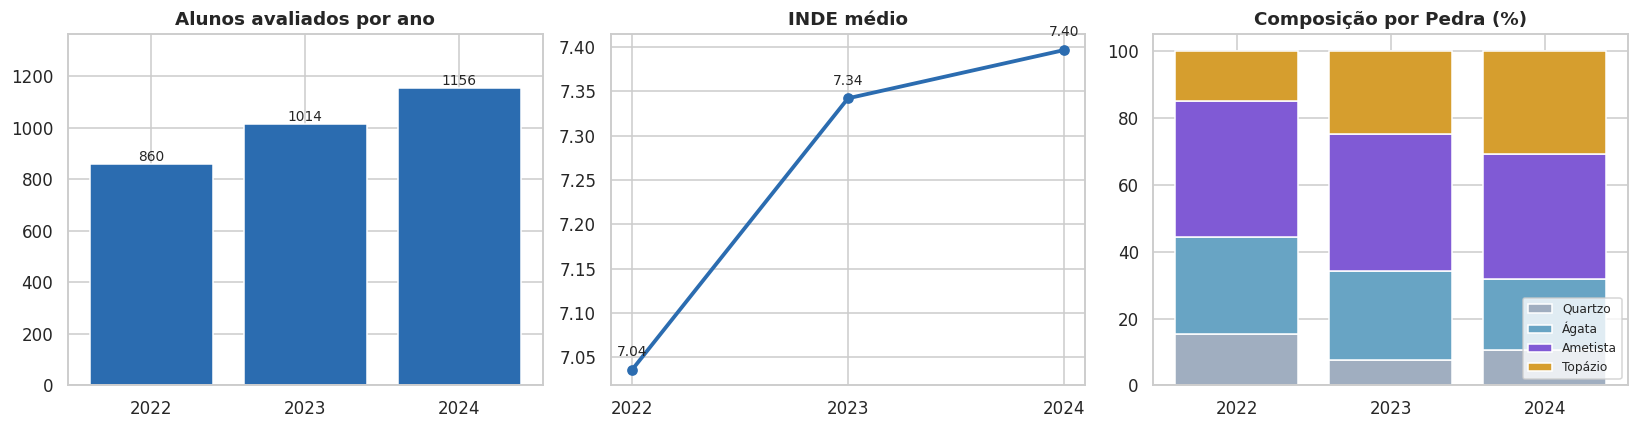

pedra,Quartzo,Ágata,Ametista,Topázio
ano,,,,
2022,15.300,29.100,40.500,15.100
2023,7.700,26.400,40.900,24.900
2024,10.600,21.300,37.100,30.900


In [23]:
fig, eixos = plt.subplots(1, 3, figsize=(15, 4))

# alunos atendidos
serie_alunos = painel.groupby("ano")["id_aluno"].nunique()
eixos[0].bar(serie_alunos.index.astype(str), serie_alunos.values, color=COR["principal"])
for x, v in zip(serie_alunos.index.astype(str), serie_alunos.values):
    eixos[0].text(x, v + 12, str(v), ha="center", fontsize=9)
eixos[0].set_title("Alunos avaliados por ano")
eixos[0].set_ylim(0, serie_alunos.max() * 1.18)

# INDE médio
inde_medio = painel.groupby("ano")["inde"].mean()
eixos[1].plot(inde_medio.index, inde_medio.values, "o-", lw=2.5, color=COR["principal"])
for ano, valor in inde_medio.items():
    eixos[1].annotate(f"{valor:.2f}", (ano, valor), textcoords="offset points",
                      xytext=(0, 9), ha="center", fontsize=9)
eixos[1].set_title("INDE médio")
eixos[1].set_xticks(ANOS)

# composição por pedra
composicao = (
    pd.crosstab(painel["ano"], painel["pedra"], normalize="index")
    .reindex(columns=ORDEM_PEDRA) * 100
)
base = np.zeros(len(composicao))
for pedra in ORDEM_PEDRA:
    eixos[2].bar(composicao.index.astype(str), composicao[pedra], bottom=base,
                 color=PALETA_PEDRA[pedra], label=pedra)
    base += composicao[pedra].values
eixos[2].set_title("Composição por Pedra (%)")
eixos[2].legend(fontsize=8, loc="lower right")

plt.tight_layout()
plt.show()

display(composicao.round(1))

O INDE médio sobe nos três anos, de 7,04 para 7,40. A composição por Pedra conta a mesma
história de forma mais concreta: **Topázio dobrou de 15,1% para 30,9%** dos alunos entre
2022 e 2024, enquanto Quartzo caiu de 15,3% para 10,6%.

A base também cresceu bastante no período — de 860 para 1.156 alunos. A Pergunta 10 volta
a esse gráfico para separar quanto da melhora é progresso individual e quanto é mudança na
composição da turma; a resposta surpreende.

---
## Pergunta 1 — Adequação de nível (IAN): qual o perfil de defasagem e como evolui?

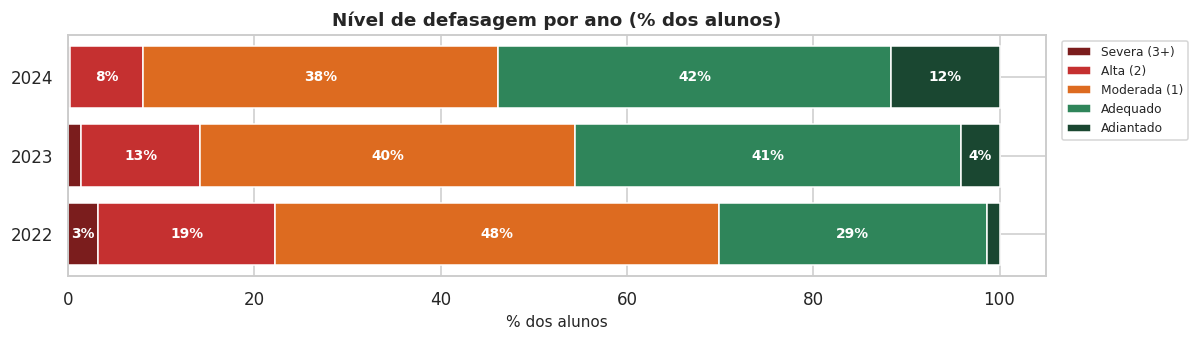

nivel_defasagem,Severa (3+),Alta (2),Moderada (1),Adequado,Adiantado
ano,,,,,
2022,3.300,19.000,47.700,28.700,1.400
2023,1.400,12.800,40.200,41.400,4.100
2024,0.300,7.800,38.100,42.100,11.700


Contagem absoluta de alunos defasados:


,sum,mean
ano,,
2022,601,0.699
2023,552,0.544
2024,534,0.462


In [24]:
dist_defasagem = (
    pd.crosstab(painel["ano"], painel["nivel_defasagem"], normalize="index")
    .reindex(columns=ROTULO_DEFASAGEM) * 100
)
cores_defasagem = ["#7b1d1d", COR["alerta"], COR["atencao"], COR["ok"], "#1a4731"]

fig, eixo = plt.subplots(figsize=(11, 3.2))
base = np.zeros(len(dist_defasagem))
for rotulo, cor in zip(ROTULO_DEFASAGEM, cores_defasagem):
    valores = dist_defasagem[rotulo].values
    eixo.barh(dist_defasagem.index.astype(str), valores, left=base, color=cor, label=rotulo)
    for y, (b, v) in enumerate(zip(base, valores)):
        if v > 3:
            eixo.text(b + v / 2, y, f"{v:.0f}%", ha="center", va="center",
                      color="white", fontsize=9, fontweight="bold")
    base += valores
eixo.set_title("Nível de defasagem por ano (% dos alunos)")
eixo.set_xlabel("% dos alunos")
eixo.legend(bbox_to_anchor=(1.01, 1), loc="upper left", fontsize=8)
plt.tight_layout()
plt.show()

display(dist_defasagem.round(1))
print("Contagem absoluta de alunos defasados:")
display(painel.groupby("ano")["defasado"].agg(["sum", "mean"]).round(3))

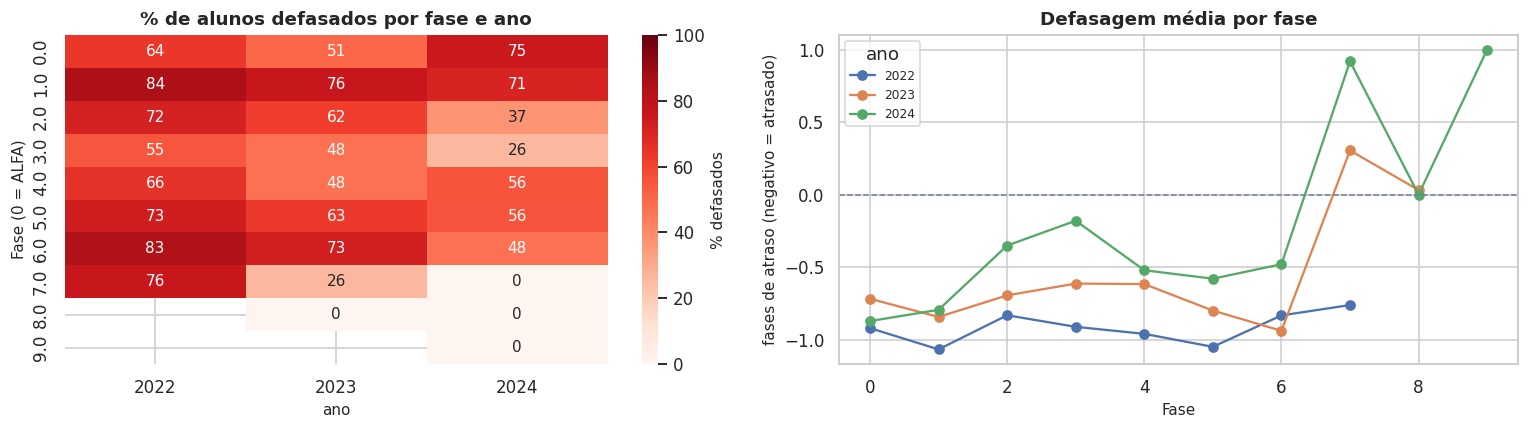

In [25]:
# onde a defasagem se concentra
mapa_fase = painel.pivot_table(index="fase", columns="ano", values="defasado", aggfunc="mean") * 100

fig, eixos = plt.subplots(1, 2, figsize=(14, 4))
sns.heatmap(mapa_fase, annot=True, fmt=".0f", cmap="Reds", vmin=0, vmax=100,
            cbar_kws={"label": "% defasados"}, ax=eixos[0])
eixos[0].set_title("% de alunos defasados por fase e ano")
eixos[0].set_ylabel("Fase (0 = ALFA)")

media_defasagem = painel.groupby(["ano", "fase"])["defasagem"].mean().unstack(0)
media_defasagem.plot(ax=eixos[1], marker="o")
eixos[1].axhline(0, color=COR["neutro"], ls="--", lw=1)
eixos[1].set_title("Defasagem média por fase")
eixos[1].set_xlabel("Fase")
eixos[1].set_ylabel("fases de atraso (negativo = atrasado)")
eixos[1].legend(title="ano", fontsize=8)

plt.tight_layout()
plt.show()

**Resposta.** O quadro melhorou de forma expressiva. Alunos em nível adequado passaram
de **28,7% para 42,1%** entre 2022 e 2024, e a defasagem severa (3 fases ou mais)
praticamente desapareceu — de 3,3% para 0,3%. Em números absolutos, os alunos defasados
caíram de **70% para 46%** do total, mesmo com a base crescendo de 860 para 1.156 alunos.

A defasagem não é uniforme: concentra-se nas fases intermediárias e finais. Nas fases
iniciais quase todos estão adequados, porque entram no nível certo; o atraso se acumula ao
longo do percurso, o que é coerente com alunos que chegam à associação já defasados na
escola regular.

Uma observação técnica que vale para todo o resto da análise: o **IAN assume apenas três
valores** (2,5, 5 e 10). Ele não é uma medida contínua de adequação, é uma classificação
em degraus derivada da defasagem. Isso limita seu poder de discriminar alunos e explica
por que, mais adiante, ele aparece pouco correlacionado com os demais indicadores.

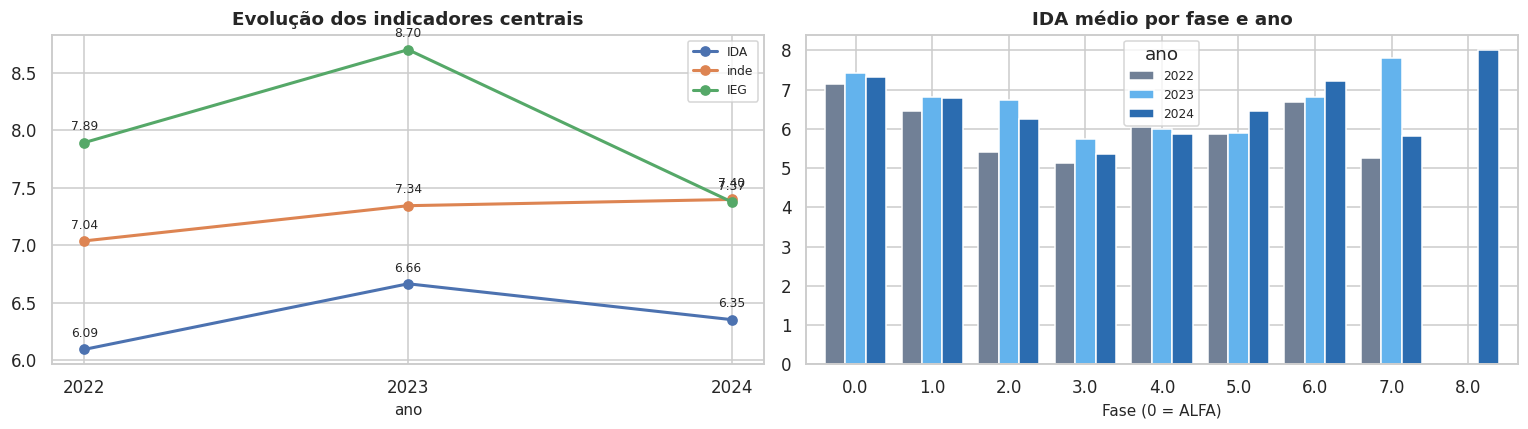

,IDA,IEG,IPS,IAA,IPV,IAN,inde
ano,,,,,,,
2022,6.093,7.891,6.905,8.274,7.254,6.424,7.036
2023,6.663,8.699,5.120,6.903,8.028,7.244,7.342
2024,6.351,7.375,6.830,8.544,7.354,7.684,7.397


In [26]:
fig, eixos = plt.subplots(1, 2, figsize=(14, 4))

# evolução do IDA e do INDE
serie = painel.groupby("ano")[["IDA", "inde", "IEG"]].mean()
serie.plot(ax=eixos[0], marker="o", lw=2)
for coluna in serie.columns:
    for ano, valor in serie[coluna].items():
        eixos[0].annotate(f"{valor:.2f}", (ano, valor), textcoords="offset points",
                          xytext=(0, 8), ha="center", fontsize=8)
eixos[0].set_title("Evolução dos indicadores centrais")
eixos[0].set_xticks(ANOS)
eixos[0].legend(fontsize=8)

# IDA por fase
ida_fase = painel.pivot_table(index="fase", columns="ano", values="IDA", aggfunc="mean")
ida_fase.plot(kind="bar", ax=eixos[1], width=0.8,
              color=[COR["neutro"], COR["apoio"], COR["principal"]])
eixos[1].set_title("IDA médio por fase e ano")
eixos[1].set_xlabel("Fase (0 = ALFA)")
eixos[1].tick_params(axis="x", rotation=0)
eixos[1].legend(title="ano", fontsize=8)

plt.tight_layout()
plt.show()

display(painel.groupby("ano")[["IDA", "IEG", "IPS", "IAA", "IPV", "IAN", "inde"]]
        .mean().round(3))

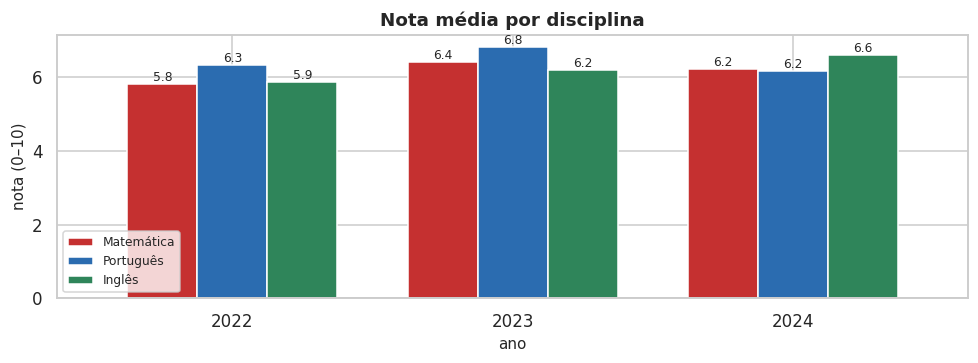

,nota_mat,nota_por,nota_ing
ano,,,
2022,5.810,6.320,5.880
2023,6.410,6.820,6.200
2024,6.230,6.180,6.600


In [27]:
# notas por disciplina — o IDA é média das avaliações, vale abrir
notas = painel.groupby("ano")[["nota_mat", "nota_por", "nota_ing"]].mean()
eixo = notas.plot(kind="bar", figsize=(9, 3.4), width=0.75,
                  color=[COR["alerta"], COR["principal"], COR["ok"]])
eixo.set_title("Nota média por disciplina")
eixo.set_ylabel("nota (0–10)")
eixo.tick_params(axis="x", rotation=0)
eixo.legend(["Matemática", "Português", "Inglês"], fontsize=8)
for container in eixo.containers:
    eixo.bar_label(container, fmt="%.1f", fontsize=8)
plt.tight_layout()
plt.show()

display(notas.round(2))

**Resposta.** O IDA **melhorou**: 6,09 em 2022 → 6,66 em 2023 → 6,35 em 2024. É um
avanço real sobre 2022, com recuo em 2024 — e o IDA é o indicador mais baixo dos sete, o
que o torna o principal gargalo do INDE.

Por disciplina não existe um vilão único: as três notas caminham juntas na faixa de 6.
Matemática foi a menor em 2022 (5,81), mas em 2024 quem ficou para trás foi português
(6,18). O problema não é uma matéria específica e sim o **patamar geral**, que se mantém
em torno de 6 num indicador que vai até 10.

A nota de inglês merece cautela: só está preenchida para cerca de um terço dos alunos, o
que torna a comparação entre disciplinas menos confiável do que parece no gráfico.

---
## Pergunta 3 — Engajamento (IEG) tem relação direta com IDA e IPV?

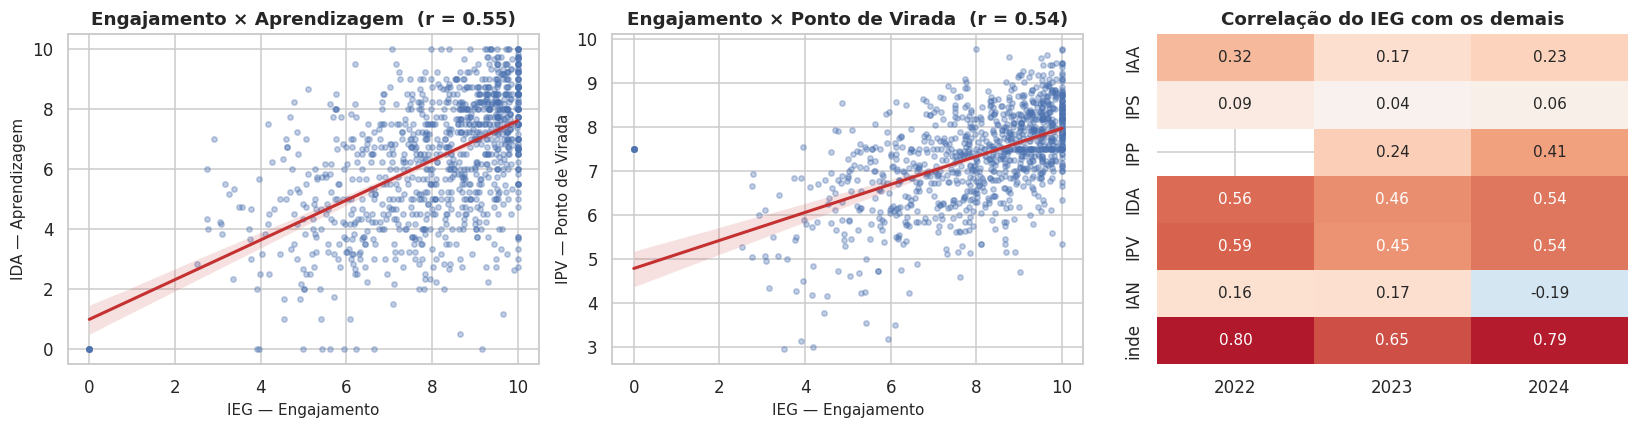

In [28]:
fig, eixos = plt.subplots(1, 3, figsize=(15, 4))

dados_2024 = painel[painel["ano"] == 2024].dropna(subset=["IEG", "IDA", "IPV"])

for eixo, (x, y) in zip(eixos[:2], [("IEG", "IDA"), ("IEG", "IPV")]):
    sns.regplot(data=dados_2024, x=x, y=y, ax=eixo, scatter_kws={"s": 12, "alpha": 0.35},
                line_kws={"color": COR["alerta"], "lw": 2})
    r = dados_2024[x].corr(dados_2024[y])
    eixo.set_title(f"{NOME_INDICADOR[x]} × {NOME_INDICADOR[y]}  (r = {r:.2f})")
    eixo.set_xlabel(f"{x} — {NOME_INDICADOR[x]}")
    eixo.set_ylabel(f"{y} — {NOME_INDICADOR[y]}")

# correlação do IEG com todo o resto, ano a ano
correlacoes = pd.DataFrame({
    ano: painel[painel["ano"] == ano][INDICADORES + ["inde"]].corr()["IEG"]
    for ano in ANOS
}).drop("IEG")
sns.heatmap(correlacoes, annot=True, fmt=".2f", cmap="RdBu_r", center=0,
            vmin=-1, vmax=1, ax=eixos[2], cbar=False)
eixos[2].set_title("Correlação do IEG com os demais")

plt.tight_layout()
plt.show()

In [29]:
# o engajamento traduz-se em desempenho? faixas de IEG × IDA médio
faixas = pd.cut(painel["IEG"], bins=[0, 5, 6, 7, 8, 9, 10],
                labels=["<5", "5–6", "6–7", "7–8", "8–9", "9–10"])
tabela = painel.groupby(faixas, observed=True).agg(
    alunos=("IEG", "size"),
    IDA_medio=("IDA", "mean"),
    IPV_medio=("IPV", "mean"),
    INDE_medio=("inde", "mean"),
    pct_defasado=("defasado", "mean"),
).round(2)
tabela["pct_defasado"] = (tabela["pct_defasado"] * 100).round(1)
display(tabela)

,alunos,IDA_medio,IPV_medio,INDE_medio,pct_defasado
IEG,,,,,
<5,129,3.630,5.890,5.300,78.000
5–6,150,4.820,6.510,6.130,64.000
6–7,248,5.140,6.870,6.440,67.000
7–8,467,5.880,7.250,6.930,65.000
8–9,758,6.560,7.600,7.340,62.000
9–10,1092,7.310,8.130,7.960,50.000


**Resposta.** Sim, e é uma das relações mais fortes da base. O IEG correlaciona
**0,54 com o IDA** e **0,54 com o IPV** em 2024, e a relação é monótona sem exceção:
alunos na faixa de IEG 9–10 têm IDA médio de **7,3**, contra **3,6** na faixa abaixo de 5.
A proporção de defasados cai de 78% para 50% entre as duas pontas.

A leitura prática é a direção: engajamento é o indicador mais **acionável** dos sete —
depende de presença, entrega de tarefas e participação, coisas sobre as quais a equipe
pedagógica age diretamente. Desempenho e ponto de virada são consequências mais difíceis
de atacar de frente.

---
## Pergunta 4 — A autoavaliação (IAA) é coerente com o desempenho real?

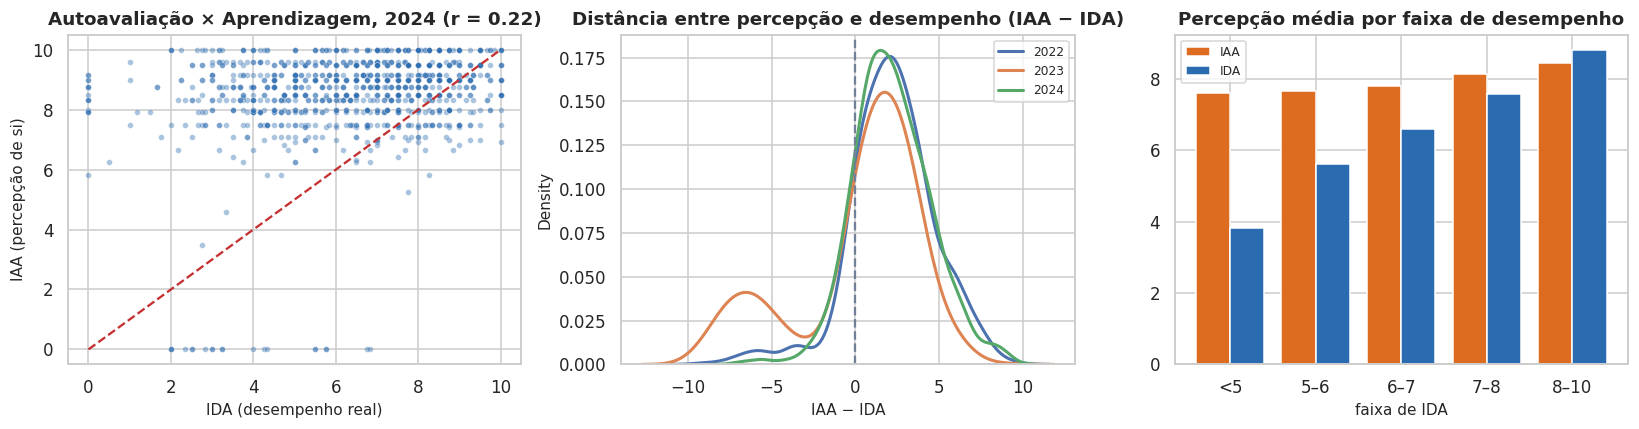

Correlação IAA × IDA por ano: {2022: np.float64(0.21), 2023: np.float64(0.1), 2024: np.float64(0.22)}
Correlação IAA × IEG por ano: {2022: np.float64(0.32), 2023: np.float64(0.17), 2024: np.float64(0.23)}


In [30]:
dados = painel.dropna(subset=["IAA", "IDA"]).copy()
dados["diferenca"] = dados["IAA"] - dados["IDA"]

fig, eixos = plt.subplots(1, 3, figsize=(15, 4))

sns.scatterplot(data=dados[dados["ano"] == 2024], x="IDA", y="IAA", ax=eixos[0],
                s=14, alpha=0.4, color=COR["principal"])
eixos[0].plot([0, 10], [0, 10], ls="--", color=COR["alerta"], lw=1.5)
r_2024 = dados[dados['ano'] == 2024]['IAA'].corr(dados[dados['ano'] == 2024]['IDA'])
eixos[0].set_title(f"Autoavaliação × Aprendizagem, 2024 (r = {r_2024:.2f})")
eixos[0].set_xlabel("IDA (desempenho real)")
eixos[0].set_ylabel("IAA (percepção de si)")

for ano in ANOS:
    sns.kdeplot(dados[dados["ano"] == ano]["diferenca"], ax=eixos[1], label=str(ano), lw=2)
eixos[1].axvline(0, color=COR["neutro"], ls="--")
eixos[1].set_title("Distância entre percepção e desempenho (IAA − IDA)")
eixos[1].set_xlabel("IAA − IDA")
eixos[1].legend(fontsize=8)

perfil = dados.groupby(pd.cut(dados["IDA"], bins=[0, 5, 6, 7, 8, 10],
                              labels=["<5", "5–6", "6–7", "7–8", "8–10"]),
                       observed=True)[["IAA", "IDA"]].mean()
perfil.plot(kind="bar", ax=eixos[2], color=[COR["atencao"], COR["principal"]], width=0.8)
eixos[2].set_title("Percepção média por faixa de desempenho")
eixos[2].set_xlabel("faixa de IDA")
eixos[2].tick_params(axis="x", rotation=0)
eixos[2].legend(fontsize=8)

plt.tight_layout()
plt.show()

print(f"Correlação IAA × IDA por ano: "
      f"{ {a: round(painel[painel.ano==a]['IAA'].corr(painel[painel.ano==a]['IDA']), 2) for a in ANOS} }")
print(f"Correlação IAA × IEG por ano: "
      f"{ {a: round(painel[painel.ano==a]['IAA'].corr(painel[painel.ano==a]['IEG']), 2) for a in ANOS} }")

In [31]:
# quem se superestima muito? esse é o grupo de risco silencioso
dados["descolamento"] = pd.cut(
    dados["diferenca"], bins=[-np.inf, -1, 1, 3, np.inf],
    labels=["Subestima", "Coerente", "Superestima", "Superestima muito"],
)
resumo_percepcao = dados.groupby("descolamento", observed=True).agg(
    alunos=("IAA", "size"),
    IDA_medio=("IDA", "mean"),
    IEG_medio=("IEG", "mean"),
    INDE_medio=("inde", "mean"),
    pct_defasado=("defasado", "mean"),
).round(2)
resumo_percepcao["pct_defasado"] = (resumo_percepcao["pct_defasado"] * 100).round(1)
resumo_percepcao["% do total"] = (resumo_percepcao["alunos"] / len(dados) * 100).round(1)
display(resumo_percepcao)

,alunos,IDA_medio,IEG_medio,INDE_medio,pct_defasado,% do total
descolamento,,,,,,
Subestima,337,6.760,8.130,6.730,59.000,11.800
Coerente,651,8.110,8.850,7.940,55.000,22.800
Superestima,1002,6.830,8.490,7.530,59.000,35.100
Superestima muito,861,4.380,7.490,6.670,63.000,30.200


**Resposta.** A coerência é **muito fraca** — mais fraca do que se esperaria. A
correlação entre IAA e IDA fica entre **0,10 e 0,22** conforme o ano, contra 0,54 entre
IEG e IDA. A nuvem de pontos fica quase toda **acima** da diagonal: os alunos se avaliam
sistematicamente melhor do que o desempenho indica.

O grupo mais preocupante é o que se superestima em mais de 3 pontos: são **30% de todos os
registros**, com IDA médio de 4,4 — o mais baixo de todos os grupos — engajamento apenas
mediano e a maior taxa de defasagem (63%). São alunos com dificuldade real que não
percebem o problema e, por isso, não pedem ajuda. Dificilmente aparecem em encaminhamentos
espontâneos, o que faz deles um público natural para busca ativa.

Na outra ponta, o grupo "coerente" tem o melhor desempenho de todos (IDA 8,1). Saber onde
se está parece andar junto com ir bem.

---
## Pergunta 5 — Há padrões psicossociais (IPS) que antecedem quedas?

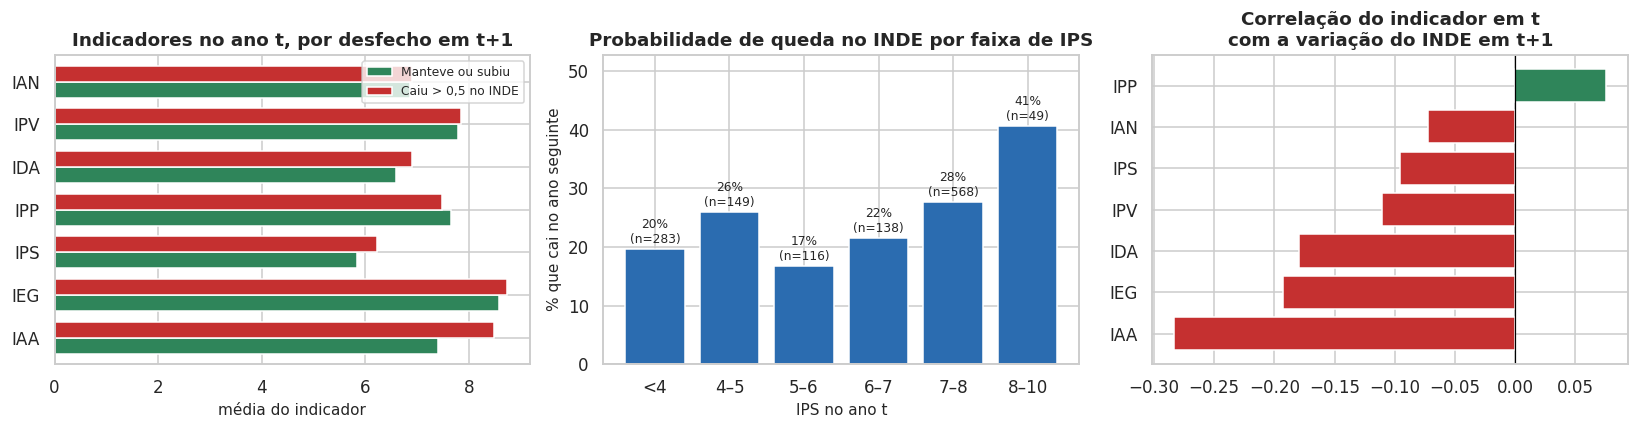

,alunos,pct_queda
IPS,,
<4,283,19.700
4–5,149,26.000
5–6,116,16.800
6–7,138,21.500
7–8,568,27.600
8–10,49,40.500


In [32]:
# comparar o IPS de hoje com o que acontece no ano seguinte
com_futuro = painel_f[painel_f["tem_ano_seguinte"]].copy()
com_futuro["caiu_inde"] = com_futuro["var_inde"] < -0.5
com_futuro["piorou_defasagem"] = com_futuro["var_defasagem"] < 0

fig, eixos = plt.subplots(1, 3, figsize=(15, 4))

# IPS atual × queda futura
comparativo = com_futuro.groupby("caiu_inde")[INDICADORES].mean().T
comparativo.columns = ["Manteve ou subiu", "Caiu > 0,5 no INDE"]
comparativo.plot(kind="barh", ax=eixos[0], color=[COR["ok"], COR["alerta"]], width=0.75)
eixos[0].set_title("Indicadores no ano t, por desfecho em t+1")
eixos[0].set_xlabel("média do indicador")
eixos[0].legend(fontsize=8)

# faixas de IPS × probabilidade de queda
faixa_ips = pd.cut(com_futuro["IPS"], bins=[0, 4, 5, 6, 7, 8, 10],
                   labels=["<4", "4–5", "5–6", "6–7", "7–8", "8–10"])
risco_ips = com_futuro.groupby(faixa_ips, observed=True).agg(
    alunos=("IPS", "size"), pct_queda=("caiu_inde", "mean"),
)
eixos[1].bar(risco_ips.index.astype(str), risco_ips["pct_queda"] * 100,
             color=COR["principal"])
for x, (v, n) in enumerate(zip(risco_ips["pct_queda"] * 100, risco_ips["alunos"])):
    eixos[1].text(x, v + 1, f"{v:.0f}%\n(n={n})", ha="center", fontsize=8)
eixos[1].set_title("Probabilidade de queda no INDE por faixa de IPS")
eixos[1].set_xlabel("IPS no ano t")
eixos[1].set_ylabel("% que cai no ano seguinte")
eixos[1].set_ylim(0, risco_ips["pct_queda"].max() * 130)

# correlação de cada indicador em t com a variação futura
correl_futuro = pd.Series({
    ind: com_futuro[ind].corr(com_futuro["var_inde"]) for ind in INDICADORES
}).sort_values()
cores = [COR["alerta"] if v < 0 else COR["ok"] for v in correl_futuro]
eixos[2].barh(correl_futuro.index, correl_futuro.values, color=cores)
eixos[2].axvline(0, color="black", lw=0.8)
eixos[2].set_title("Correlação do indicador em t\ncom a variação do INDE em t+1")

plt.tight_layout()
plt.show()

display(risco_ips.assign(pct_queda=lambda d: (d["pct_queda"] * 100).round(1)))

**Resposta.** O IPS **não funciona como sinal antecedente** — e o resultado é o oposto do
esperado. A probabilidade de queda no INDE não diminui conforme o IPS melhora; ela
**aumenta**: 19,7% na faixa abaixo de 4 contra 40,5% na faixa de 8 a 10.

Isso não significa que estar bem psicossocialmente faça mal. É **regressão à média**: quem
está no topo de qualquer indicador tem mais espaço para cair no ano seguinte, e menos para
subir. O mesmo padrão aparece em todos os indicadores — as correlações entre o nível atual
e a variação futura são negativas em bloco.

A conclusão útil para a associação é metodológica: **o nível de um indicador num único ano
não antecipa queda**. Para transformar o IPS em alerta precoce seria preciso medi-lo com
mais frequência e olhar a *trajetória*, não a fotografia anual. O IPS também é o indicador
menos correlacionado com o INDE (0,20), o que reforça que ele mede uma dimensão à parte.

---
## Pergunta 6 — O IPP confirma ou contradiz a defasagem do IAN?

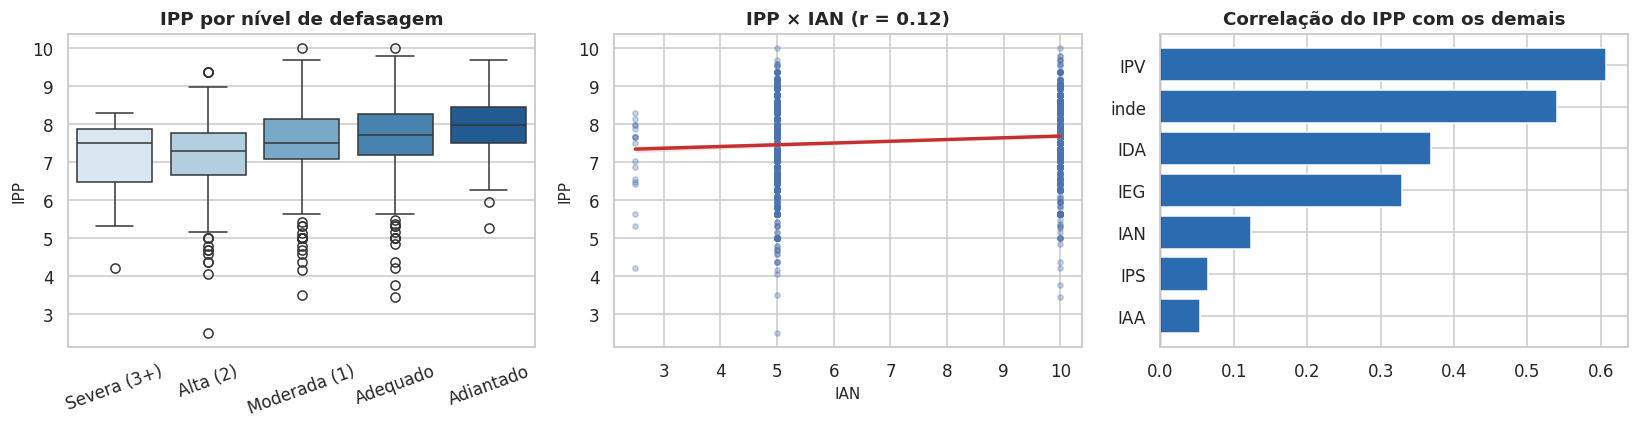

,alunos,IPP_medio,IAN_medio,IDA_medio
nivel_defasagem,,,,
Severa (3+),17,7.010,2.500,5.100
Alta (2),220,7.110,5.000,5.890
Moderada (1),847,7.550,5.000,6.500
Adequado,780,7.640,10.000,6.640
Adiantado,128,7.930,10.000,6.850


In [33]:
dados_ipp = painel.dropna(subset=["IPP", "IAN"])

fig, eixos = plt.subplots(1, 3, figsize=(15, 4))

sns.boxplot(data=dados_ipp, x="nivel_defasagem", y="IPP", ax=eixos[0],
            order=[r for r in ROTULO_DEFASAGEM if r in dados_ipp["nivel_defasagem"].unique()],
            palette="Blues")
eixos[0].set_title("IPP por nível de defasagem")
eixos[0].set_xlabel("")
eixos[0].tick_params(axis="x", rotation=20)

sns.regplot(data=dados_ipp, x="IAN", y="IPP", ax=eixos[1], scatter_kws={"s": 12, "alpha": 0.3},
            line_kws={"color": COR["alerta"]})
eixos[1].set_title(f"IPP × IAN (r = {dados_ipp['IPP'].corr(dados_ipp['IAN']):.2f})")

correl_ipp = dados_ipp[INDICADORES + ["inde"]].corr()["IPP"].drop("IPP").sort_values()
eixos[2].barh(correl_ipp.index, correl_ipp.values, color=COR["principal"])
eixos[2].set_title("Correlação do IPP com os demais")
eixos[2].axvline(0, color="black", lw=0.8)

plt.tight_layout()
plt.show()

display(dados_ipp.groupby("nivel_defasagem", observed=True)
        .agg(alunos=("IPP", "size"), IPP_medio=("IPP", "mean"),
             IAN_medio=("IAN", "mean"), IDA_medio=("IDA", "mean")).round(2))

**Resposta.** As duas leituras **medem coisas diferentes**. A correlação entre IPP e IAN é
de apenas **0,15**, e o IPP varia pouquíssimo entre os níveis de defasagem: 7,01 nos
severamente defasados contra 7,64 nos adequados. Existe um gradiente, mas é suave demais
para que se possa dizer que uma avaliação confirma a outra.

Faz sentido conceitual. O IAN mede uma **posição estrutural** — a que distância o aluno
está da fase ideal para a idade dele —, enquanto o IPP mede a **avaliação psicopedagógica
atual**: como ele aprende, como responde ao acompanhamento. Um aluno pode estar duas fases
atrasado por ter chegado tarde ao programa e ainda assim ter excelente avaliação
psicopedagógica.

Some-se a isso que o IPP é o indicador de menor dispersão de todos (desvio padrão 0,94):
quase todo mundo recebe nota entre 7 e 8. Um indicador que não varia não distingue
ninguém.

Consequência prática: defasagem **não** deve ser lida como dificuldade de aprendizagem.
São dimensões distintas e a associação faz bem em manter as duas — mas o IPP, do jeito que
está calibrado hoje, agrega pouca informação nova.

---
## Pergunta 7 — O que mais influencia o Ponto de Virada (IPV)?

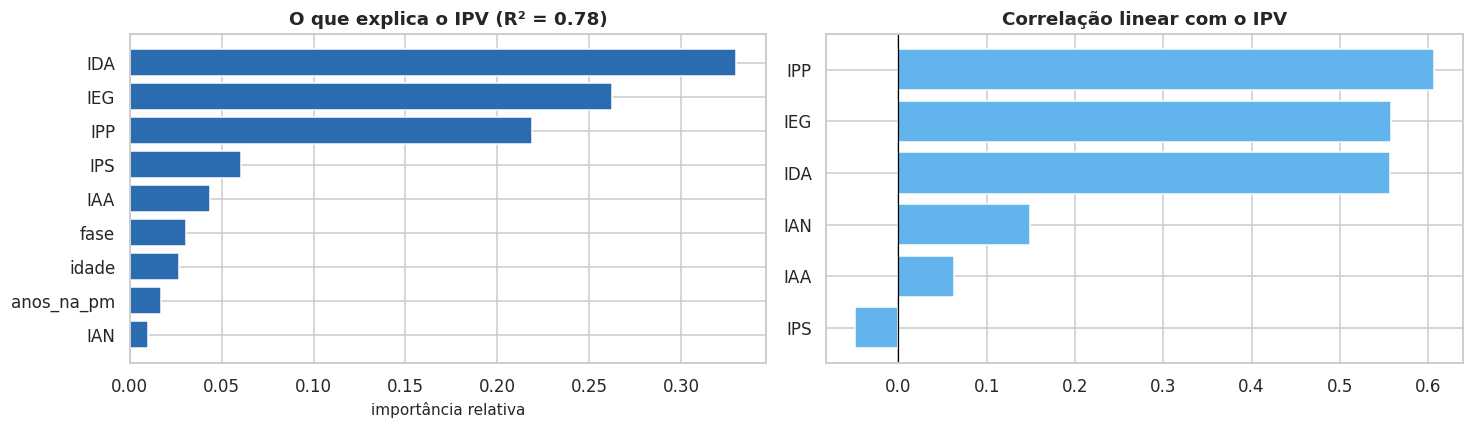

Importância (%):
IDA          33.000
IEG          26.200
IPP          21.900
IPS           6.100
IAA           4.400
fase          3.100
idade         2.700
anos_na_pm    1.700
IAN           1.000


In [34]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.impute import SimpleImputer

# como 'Atingiu PV' só existe em 2022, trabalhamos com o indicador numérico IPV
preditoras = ["IAA", "IEG", "IPS", "IPP", "IDA", "IAN", "idade", "anos_na_pm", "fase"]
dados_ipv = painel.dropna(subset=["IPV"])
X = SimpleImputer(strategy="median").fit_transform(dados_ipv[preditoras])
y = dados_ipv["IPV"]

floresta = RandomForestRegressor(n_estimators=400, min_samples_leaf=5,
                                 random_state=SEMENTE).fit(X, y)
importancias = pd.Series(floresta.feature_importances_, index=preditoras).sort_values()

fig, eixos = plt.subplots(1, 2, figsize=(13.5, 4))
eixos[0].barh(importancias.index, importancias.values, color=COR["principal"])
eixos[0].set_title(f"O que explica o IPV (R² = {floresta.score(X, y):.2f})")
eixos[0].set_xlabel("importância relativa")

correl_ipv = dados_ipv[INDICADORES].corr()["IPV"].drop("IPV").sort_values()
eixos[1].barh(correl_ipv.index, correl_ipv.values, color=COR["apoio"])
eixos[1].set_title("Correlação linear com o IPV")
eixos[1].axvline(0, color="black", lw=0.8)

plt.tight_layout()
plt.show()

print("Importância (%):")
print((importancias.sort_values(ascending=False) * 100).round(1).to_string())

In [35]:
# em 2022 existe o booleano; vale conferir o que separa quem atingiu de quem não
pv_2022 = painel[(painel["ano"] == 2022) & painel["atingiu_pv"].notna()]
comparacao_pv = pv_2022.groupby("atingiu_pv")[INDICADORES + ["inde", "defasagem"]].mean().T
comparacao_pv.columns = ["Não atingiu", "Atingiu"]
comparacao_pv["diferença"] = comparacao_pv["Atingiu"] - comparacao_pv["Não atingiu"]
display(comparacao_pv.round(2).sort_values("diferença", ascending=False))
print(f"Alunos que atingiram o Ponto de Virada em 2022: "
      f"{pv_2022['atingiu_pv'].sum()} de {len(pv_2022)} ({pv_2022['atingiu_pv'].mean():.1%})")

,Não atingiu,Atingiu,diferença
IDA,5.824,7.869,2.045
IPV,7.011,8.856,1.845
inde,6.866,8.164,1.298
IEG,7.722,9.012,1.290
IAA,8.185,8.867,0.683
IAN,6.355,6.881,0.525
IPS,6.843,7.315,0.472
defasagem,-0.979,-0.708,0.271
IPP,<NA>,<NA>,<NA>


Alunos que atingiram o Ponto de Virada em 2022: 113 de 860 (13.1%)


**Resposta.** O IPV é explicado quase inteiramente por três indicadores:
**IDA (33%), IEG (26%) e IPP (22%)** somam mais de 80% da importância. Idade, fase e tempo
de casa juntos não chegam a 8%.

O recorte de 2022, único ano com o campo booleano preenchido, confirma pelo outro lado:
entre os 113 alunos que atingiram o Ponto de Virada, a maior diferença está em
**IDA (+2,0 pontos)** e IEG (+1,3), enquanto a diferença em IPS é de apenas 0,5 e a
defasagem quase não distingue os grupos.

Ou seja: o ponto de virada é **construído**, não é atributo do aluno. Ele acompanha
comportamento — frequência, entrega, participação — e não características fixas como
idade, fase ou tempo de programa. É uma boa notícia para o desenho de intervenções.

---
## Pergunta 8 — Que combinações de indicadores elevam mais o INDE?

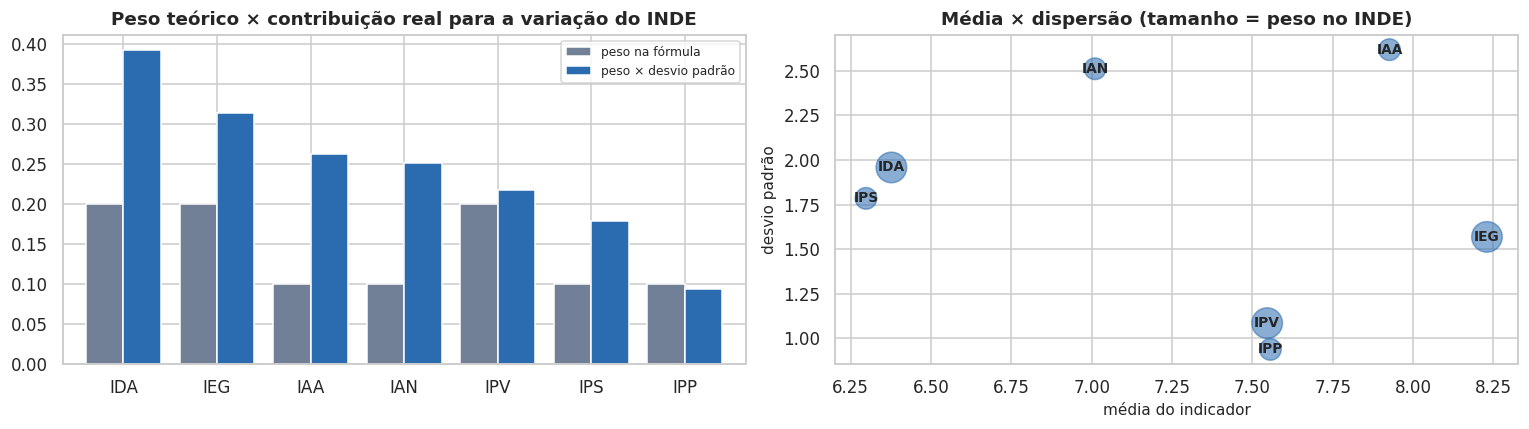

,peso_no_INDE,correlacao,desvio_padrao,media,contribuicao_pratica
IDA,0.200,0.785,1.958,6.377,0.392
IEG,0.200,0.745,1.568,8.230,0.314
IAA,0.100,0.397,2.618,7.927,0.262
IAN,0.100,0.405,2.511,7.011,0.251
IPV,0.200,0.721,1.085,7.546,0.217
IPS,0.100,0.200,1.784,6.298,0.178
IPP,0.100,0.540,0.938,7.556,0.094


In [36]:
# atenção: o INDE é média ponderada dos próprios indicadores, então correlacionar
# é parcialmente circular. A leitura útil é comparar peso teórico × poder de
# discriminação real entre alunos.
PESOS_DIVULGADOS = {"IAN": 0.10, "IDA": 0.20, "IEG": 0.20, "IAA": 0.10,
                    "IPS": 0.10, "IPP": 0.10, "IPV": 0.20}

dados_inde = painel.dropna(subset=["inde"])
analise = pd.DataFrame({
    "peso_no_INDE": pd.Series(PESOS_DIVULGADOS),
    "correlacao": dados_inde[INDICADORES].corrwith(dados_inde["inde"]),
    "desvio_padrao": dados_inde[INDICADORES].std(),
    "media": dados_inde[INDICADORES].mean(),
})
analise["contribuicao_pratica"] = analise["peso_no_INDE"] * analise["desvio_padrao"]
analise = analise.sort_values("contribuicao_pratica", ascending=False)

fig, eixos = plt.subplots(1, 2, figsize=(14, 4))
analise[["peso_no_INDE", "contribuicao_pratica"]].plot(
    kind="bar", ax=eixos[0], color=[COR["neutro"], COR["principal"]], width=0.8)
eixos[0].set_title("Peso teórico × contribuição real para a variação do INDE")
eixos[0].tick_params(axis="x", rotation=0)
eixos[0].legend(["peso na fórmula", "peso × desvio padrão"], fontsize=8)

eixos[1].scatter(analise["media"], analise["desvio_padrao"],
                 s=analise["peso_no_INDE"] * 2000, alpha=0.55, color=COR["principal"])
for indicador, linha in analise.iterrows():
    eixos[1].annotate(indicador, (linha["media"], linha["desvio_padrao"]),
                      ha="center", va="center", fontsize=9, fontweight="bold")
eixos[1].set_title("Média × dispersão (tamanho = peso no INDE)")
eixos[1].set_xlabel("média do indicador")
eixos[1].set_ylabel("desvio padrão")

plt.tight_layout()
plt.show()

display(analise.round(3))

In [37]:
# perfil dos alunos no topo: o que distingue um Topázio de um Ametista?
perfil_pedra = painel.groupby("pedra", observed=True)[INDICADORES + ["inde"]].mean().T
perfil_pedra["salto_Ametista→Topázio"] = perfil_pedra["Topázio"] - perfil_pedra["Ametista"]
display(perfil_pedra.round(2).sort_values("salto_Ametista→Topázio", ascending=False))

pedra,Quartzo,Ágata,Ametista,Topázio,salto_Ametista→Topázio
IAN,5.660,6.080,7.000,8.620,1.610
IDA,3.460,5.260,6.810,8.180,1.370
inde,5.370,6.590,7.520,8.440,0.920
IPV,6.060,7.030,7.740,8.460,0.720
IEG,5.610,7.590,8.680,9.380,0.710
IAA,5.760,7.230,8.310,9.020,0.710
IPP,6.550,7.190,7.600,8.130,0.530
IPS,5.790,5.990,6.310,6.840,0.530


**Resposta.** Na fórmula, IDA, IEG e IPV pesam 20% cada e os outros quatro 10%. Mas peso
não é a mesma coisa que poder de mover a nota: o que move o INDE é peso **vezes
dispersão**. Um indicador em que todos tiram nota parecida não diferencia ninguém, por
mais que pese.

Por esse critério a dupla que mais eleva o INDE é **IDA + IEG** (0,39 e 0,31 de
contribuição prática). O caso mais interessante é o **IPV**: pesa 20% na fórmula, mas tem
a menor dispersão entre os indicadores de peso alto, então contribui menos que o IAA e o
IAN, que pesam metade. E o **IPP é o menos relevante de todos** — 10% de peso combinado
com a menor variância da base.

Comparando quem é Ametista com quem é Topázio, o salto vem de **IAN (+1,61) e IDA
(+1,37)**, muito à frente dos indicadores psicossociais (+0,53). Chegar ao topo passa por
estar no nível certo e aprender, não por ir bem nas dimensões subjetivas.

Recomendação: para subir o INDE de uma coorte, o caminho de maior retorno é atacar o IDA
usando o IEG como alavanca — engajamento é o que a equipe controla e o que puxa a
aprendizagem junto.

---
## Pergunta 10 — O programa mostra melhora consistente ao longo do ciclo?

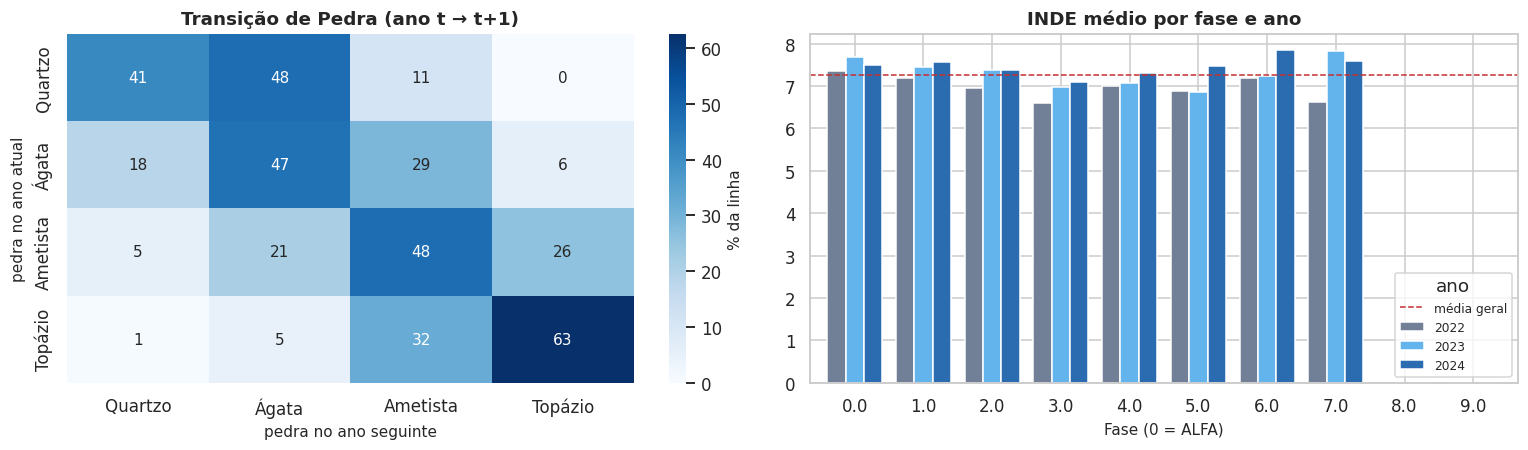

Alunos que SOBEM de pedra : 314 (25.2%)
Alunos que se MANTÊM      : 631 (50.6%)
Alunos que DESCEM de pedra: 303 (24.3%)


In [38]:
# matriz de transição entre pedras — em contagem, não em % de linha
transicao_pedra = painel_f.dropna(subset=["pedra", "pedra_prox"])
contagem = (
    pd.crosstab(transicao_pedra["pedra"], transicao_pedra["pedra_prox"])
    .reindex(index=ORDEM_PEDRA, columns=ORDEM_PEDRA).fillna(0)
)
matriz = contagem.div(contagem.sum(axis=1), axis=0) * 100

fig, eixos = plt.subplots(1, 2, figsize=(14, 4.2))
sns.heatmap(matriz, annot=True, fmt=".0f", cmap="Blues", ax=eixos[0],
            cbar_kws={"label": "% da linha"})
eixos[0].set_title("Transição de Pedra (ano t → t+1)")
eixos[0].set_xlabel("pedra no ano seguinte")
eixos[0].set_ylabel("pedra no ano atual")

evolucao = painel.groupby(["ano", "fase"])["inde"].mean().unstack(0)
evolucao.plot(kind="bar", ax=eixos[1], width=0.8,
              color=[COR["neutro"], COR["apoio"], COR["principal"]])
eixos[1].axhline(painel["inde"].mean(), ls="--", color=COR["alerta"], lw=1,
                 label="média geral")
eixos[1].set_title("INDE médio por fase e ano")
eixos[1].set_xlabel("Fase (0 = ALFA)")
eixos[1].tick_params(axis="x", rotation=0)
eixos[1].legend(title="ano", fontsize=8)

plt.tight_layout()
plt.show()

valores = contagem.values
subiu, manteve, desceu = np.tril(valores, -1).sum(), np.trace(valores), np.triu(valores, 1).sum()
total = valores.sum()
print(f"Alunos que SOBEM de pedra : {subiu:.0f} ({subiu/total:.1%})")
print(f"Alunos que se MANTÊM      : {manteve:.0f} ({manteve/total:.1%})")
print(f"Alunos que DESCEM de pedra: {desceu:.0f} ({desceu/total:.1%})")

Alunos com os três anos completos: 434
  melhoraram o INDE : 240 (55.3%)
  pioraram          : 194 (44.7%)
  variação média    : -0.003


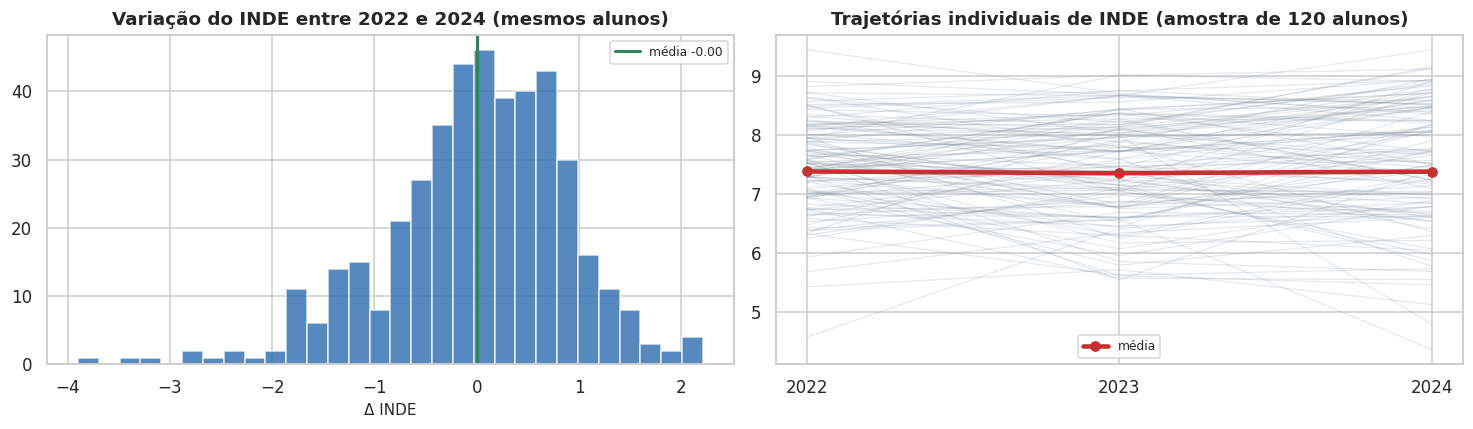

In [39]:
# alunos observados nos três anos: a trajetória individual confirma o agregado?
tres_anos = painel[painel["n_anos_observados"] == 3]
trajetoria = tres_anos.pivot_table(index="id_aluno", columns="ano", values="inde")
trajetoria = trajetoria.dropna()

variacao = trajetoria[2024] - trajetoria[2022]
print(f"Alunos com os três anos completos: {len(trajetoria)}")
print(f"  melhoraram o INDE : {(variacao > 0).sum()} ({(variacao > 0).mean():.1%})")
print(f"  pioraram          : {(variacao < 0).sum()} ({(variacao < 0).mean():.1%})")
print(f"  variação média    : {variacao.mean():+.3f}")

fig, eixos = plt.subplots(1, 2, figsize=(13.5, 4))
eixos[0].hist(variacao, bins=30, color=COR["principal"], alpha=0.8)
eixos[0].axvline(0, color=COR["alerta"], ls="--", lw=2)
eixos[0].axvline(variacao.mean(), color=COR["ok"], lw=2, label=f"média {variacao.mean():+.2f}")
eixos[0].set_title("Variação do INDE entre 2022 e 2024 (mesmos alunos)")
eixos[0].set_xlabel("Δ INDE")
eixos[0].legend(fontsize=8)

amostra = trajetoria.sample(min(120, len(trajetoria)), random_state=SEMENTE)
for _, linha in amostra.iterrows():
    eixos[1].plot(ANOS, linha.values, color=COR["neutro"], alpha=0.18, lw=0.8)
eixos[1].plot(ANOS, trajetoria.mean().values, color=COR["alerta"], lw=3, marker="o",
              label="média")
eixos[1].set_title("Trajetórias individuais de INDE (amostra de 120 alunos)")
eixos[1].set_xticks(ANOS)
eixos[1].legend(fontsize=8)

plt.tight_layout()
plt.show()

In [40]:
# de onde vem a melhora agregada: progresso individual ou troca de alunos?
linhas = []
for ano in (2023, 2024):
    entrantes = painel[(painel["ano"] == ano) & (painel["ano_ingresso"] == ano)]
    veteranos = painel[(painel["ano"] == ano) & (painel["ano_ingresso"] < ano)]
    linhas.append({"ano": ano, "grupo": "ingressantes",
                   "alunos": len(entrantes), "INDE": entrantes["inde"].mean()})
    linhas.append({"ano": ano, "grupo": "veteranos",
                   "alunos": len(veteranos), "INDE": veteranos["inde"].mean()})
display(pd.DataFrame(linhas).round(3))

# e quem saiu do programa depois de 2022?
saiu = set(painel.loc[painel["ano"] == 2022, "id_aluno"]) - set(painel.loc[painel["ano"] == 2023, "id_aluno"])
base_2022 = painel[painel["ano"] == 2022]
print(f"Alunos de 2022 que NÃO retornaram em 2023: {len(saiu)} | "
      f"INDE médio {base_2022.loc[base_2022['id_aluno'].isin(saiu), 'inde'].mean():.3f}")
print(f"Alunos de 2022 que permaneceram          : {860 - len(saiu)} | "
      f"INDE médio {base_2022.loc[~base_2022['id_aluno'].isin(saiu), 'inde'].mean():.3f}")

,ano,grupo,alunos,INDE
0,2023,ingressantes,360,7.519
1,2023,veteranos,654,7.233
2,2024,ingressantes,349,7.415
3,2024,veteranos,807,7.387


Alunos de 2022 que NÃO retornaram em 2023: 260 | INDE médio 6.513
Alunos de 2022 que permaneceram          : 600 | INDE médio 7.263


**Resposta.** Sim no agregado, **não** no acompanhamento individual — e essa diferença é
provavelmente o achado mais importante de toda a análise.

No agregado tudo melhora: o INDE médio sobe todo ano, Topázio dobra de participação, a
defasagem severa desaparece. Na matriz de transição, 25,2% dos alunos sobem de pedra
contra 24,3% que descem — praticamente empate, com metade se mantendo.

Mas entre os **434 alunos acompanhados nos três anos**, a variação média do INDE entre
2022 e 2024 é de **−0,003**. Zero. Pouco mais da metade melhorou (55%), quase metade
piorou, e os dois efeitos se anulam.

A explicação está na composição:

- Os alunos de 2022 que **não retornaram** em 2023 tinham INDE médio de **6,51**, contra
  **7,26** dos que ficaram. Quem sai é quem ia pior.
- Os **ingressantes** de 2023 chegaram com INDE médio de **7,52**, acima dos **7,23** dos
  veteranos.

Ou seja: a base melhora porque entra gente melhor e sai gente pior, não porque o mesmo
aluno evolui. Isso **não invalida o programa** — reter o aluno em dificuldade é
notoriamente difícil e a evasão seletiva é comum em projetos sociais —, mas muda
completamente a leitura.

Para a apresentação: atribuir o salto de 7,04 para 7,40 ao efeito do programa seria
incorreto. O recado honesto e mais valioso é outro — **a associação precisa olhar
retenção**, porque é na saída dos alunos com pior desempenho que está boa parte da melhora
aparente.

---
## Pergunta 11 — Insights adicionais

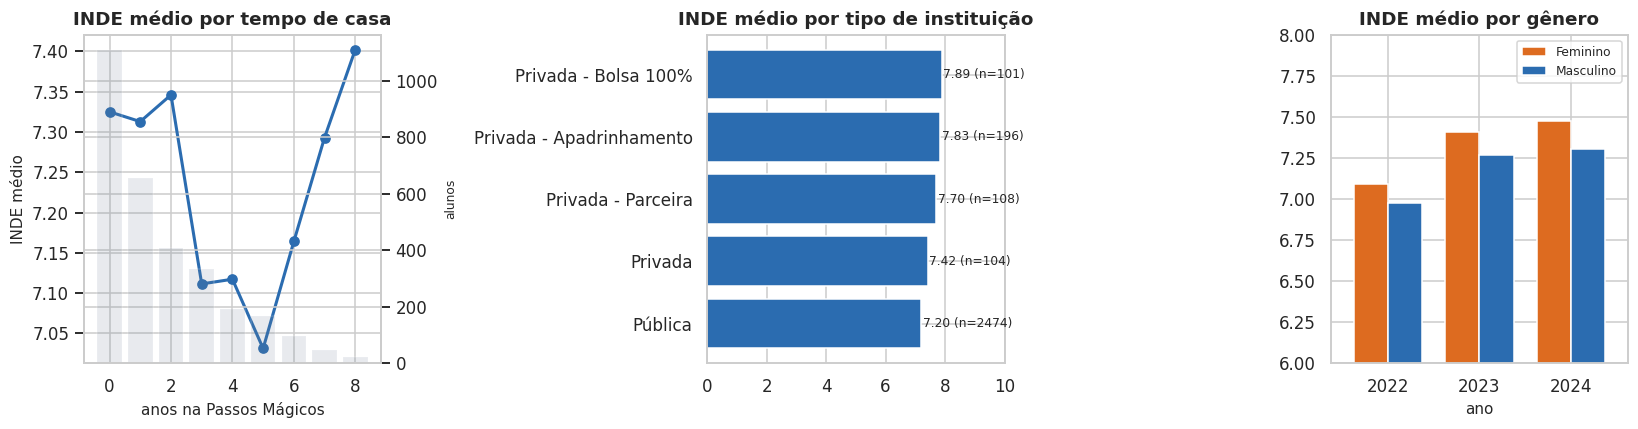

,alunos,inde,defasado
anos_na_pm,,,
0,1107,7.325,0.601
1,655,7.313,0.650
2,408,7.346,0.475
3,333,7.111,0.444
4,194,7.117,0.552
5,167,7.031,0.437
6,96,7.164,0.510
7,49,7.293,0.388
8,21,7.402,0.286


In [41]:
fig, eixos = plt.subplots(1, 3, figsize=(15, 4))

# tempo de casa
tempo = painel[painel["anos_na_pm"].between(0, 8)]
resumo_tempo = tempo.groupby("anos_na_pm").agg(
    alunos=("inde", "size"), inde=("inde", "mean"), defasado=("defasado", "mean"))
eixos[0].plot(resumo_tempo.index, resumo_tempo["inde"], "o-", color=COR["principal"], lw=2)
eixo_b = eixos[0].twinx()
eixo_b.bar(resumo_tempo.index, resumo_tempo["alunos"], alpha=0.16, color=COR["neutro"])
eixo_b.set_ylabel("alunos", fontsize=8)
eixos[0].set_title("INDE médio por tempo de casa")
eixos[0].set_xlabel("anos na Passos Mágicos")
eixos[0].set_ylabel("INDE médio")

# instituição de ensino
principais = painel["instituicao"].value_counts().head(5).index
por_instituicao = (
    painel[painel["instituicao"].isin(principais)]
    .groupby("instituicao").agg(inde=("inde", "mean"), alunos=("inde", "size"))
    .sort_values("inde")
)
eixos[1].barh(por_instituicao.index, por_instituicao["inde"], color=COR["principal"])
for y, (v, n) in enumerate(zip(por_instituicao["inde"], por_instituicao["alunos"])):
    eixos[1].text(v + 0.05, y, f"{v:.2f} (n={n})", va="center", fontsize=8)
eixos[1].set_title("INDE médio por tipo de instituição")
eixos[1].set_xlim(0, 10)

# gênero
por_genero = painel.groupby(["ano", "genero"])["inde"].mean().unstack()
por_genero.plot(kind="bar", ax=eixos[2], color=[COR["atencao"], COR["principal"]], width=0.75)
eixos[2].set_title("INDE médio por gênero")
eixos[2].tick_params(axis="x", rotation=0)
eixos[2].legend(["Feminino", "Masculino"], fontsize=8)
eixos[2].set_ylim(6, 8)

plt.tight_layout()
plt.show()

display(resumo_tempo.round(3))

In [42]:
# um recorte acionável: alunos com engajamento alto e aprendizagem baixa
ultimo = painel[painel["ano"] == 2024].dropna(subset=["IEG", "IDA"])
ultimo = ultimo.assign(
    grupo=np.select(
        [
            (ultimo["IEG"] >= 7) & (ultimo["IDA"] >= 6),
            (ultimo["IEG"] >= 7) & (ultimo["IDA"] < 6),
            (ultimo["IEG"] < 7) & (ultimo["IDA"] >= 6),
        ],
        ["Engajado e aprendendo", "Engajado mas travado", "Aprende sem engajar"],
        default="Precisa de atenção",
    )
)
quadro = ultimo.groupby("grupo").agg(
    alunos=("inde", "size"), INDE=("inde", "mean"), IEG=("IEG", "mean"),
    IDA=("IDA", "mean"), IPS=("IPS", "mean"), pct_defasado=("defasado", "mean"),
).round(2)
quadro["pct_defasado"] = (quadro["pct_defasado"] * 100).round(1)
quadro["% do total"] = (quadro["alunos"] / len(ultimo) * 100).round(1)
display(quadro.sort_values("alunos", ascending=False))

,alunos,INDE,IEG,IDA,IPS,pct_defasado,% do total
grupo,,,,,,,
Engajado e aprendendo,585,8.040,9.030,7.810,6.890,49.000,55.500
Engajado mas travado,228,7.010,8.460,4.420,6.900,50.000,21.600
Precisa de atenção,174,5.940,5.280,3.670,6.730,53.000,16.500
Aprende sem engajar,68,6.860,5.790,7.130,6.260,57.000,6.400


**Insights que não estavam nas perguntas:**

**Tempo de casa não prevê desempenho.** A curva de INDE por anos na Passos Mágicos é
essencialmente plana — 7,33 para quem chegou este ano, 7,11 para quem tem três anos de
casa, 7,29 para quem tem sete. Não há acúmulo de benefício com o tempo, o que conversa
diretamente com o achado da Pergunta 10. O que melhora com o tempo é a **defasagem**: cai
de 60% para 29% entre o primeiro e o oitavo ano, sugerindo que o programa é eficaz em
recolocar o aluno no nível certo, mesmo sem elevar o INDE.

**Existe um grupo "engajado mas travado".** 228 alunos (22% da base de 2024) têm IEG de
8,5 e IDA de 4,4 — fazem tudo o que se pede e ainda assim não avançam na aprendizagem. É o
grupo com melhor custo-benefício de intervenção pedagógica, porque a adesão já está
garantida: o que falta é método, não vontade.

**O IPS de 2023 tem um problema de medição.** A média cai de 6,91 (2022) para 5,12 (2023)
e volta para 6,83 (2024). Uma oscilação dessa magnitude em um ano, seguida de retorno ao
patamar anterior, tem muito mais cara de mudança de critério de avaliação do que de
fenômeno real. Vale confirmar com a associação antes de usar o IPS em série histórica.

---
# Parte 4 — Modelo preditivo de risco de defasagem

> *"Quais padrões nos indicadores permitem identificar alunos em risco antes de queda no
> desempenho ou aumento da defasagem? Construa um modelo preditivo que mostre uma
> probabilidade do aluno entrar em risco de defasagem."*

## 4.1 Desenho do problema

Isto é um problema **longitudinal**: as variáveis explicativas vêm do ano `t` e a resposta
do ano `t+1`. Cada linha da base de modelagem é um aluno observado em dois anos
consecutivos.

Três decisões precisam ser explicitadas antes de qualquer código.

**Por que não usar o Ponto de Virada como alvo.** O campo `Atingiu PV` está vazio em 2023
e 2024 (Conclusão 1). Sem rótulo nos anos recentes não há como treinar nem validar.

**Por que a divisão treino/teste é temporal.** Separar aleatoriamente misturaria o mesmo
aluno nos dois lados e inflaria as métricas. Usar um arquivo como treino e outro como
teste também não serve: são recortes temporais da mesma população, não amostras
independentes. O corte correto reproduz o uso real — treinar com o passado e prever o
próximo ciclo.

**Nenhuma variável do ano t+1 entra como preditora.** Só entra o que a associação
efetivamente sabe no momento em que precisaria agir.

In [43]:
COLUNAS_MODELO = [
    "id_aluno", "ano", "genero", "idade", "anos_na_pm", "instituicao",
    "fase", "fase_ideal", "defasagem", "inde", "pedra", *INDICADORES,
    "nota_mat", "nota_por", "nota_ing", "qtd_avaliadores",
]

transicoes = painel_f[painel_f["defasagem_prox"].notna()][
    COLUNAS_MODELO + ["defasagem_prox", "inde_prox", "fase_prox", "var_defasagem", "var_inde"]
].copy().reset_index(drop=True)

print("Pares aluno (t → t+1):", len(transicoes))
display(transicoes.groupby("ano").size().rename("pares").to_frame().T)

Pares aluno (t → t+1): 1365


ano,2022,2023
pares,600,765


## 4.2 Definição do alvo

O enunciado fala em "entrar em risco de defasagem". Três definições são defensáveis e vale
comparar antes de escolher.

In [44]:
candidatos = pd.DataFrame({
    "A_estara_defasado": (transicoes["defasagem_prox"] < 0),
    "B_piorou": (transicoes["var_defasagem"] < 0),
    "C_entrou_ou_aprofundou": (transicoes["var_defasagem"] < 0) & (transicoes["defasagem_prox"] < 0),
}).astype(int)

comparacao = candidatos.assign(ano=transicoes["ano"]).groupby("ano").agg(["mean", "sum"])
display((comparacao.xs("mean", axis=1, level=1) * 100).round(1))
display(comparacao.xs("sum", axis=1, level=1))

,A_estara_defasado,B_piorou,C_entrou_ou_aprofundou
ano,,,
2022,61.000,17.300,16.300
2023,40.300,17.300,14.900


,A_estara_defasado,B_piorou,C_entrou_ou_aprofundou
ano,,,
2022,366,104,98
2023,308,132,114


**A** é dominada por persistência: quem já está defasado tende a continuar, então o
modelo aprenderia pouco e a associação ganharia pouco — 61% dos casos em 2022 já são
positivos. **B** conta como risco quem apenas deixou de estar adiantado e passou a
adequado, o que não é risco de verdade.

**C** é a escolha: *o aluno vai entrar em defasagem ou aprofundar a que já tem*. A
prevalência fica em torno de 15%, estável nas duas transições, e o evento é
inequivocamente ruim.

In [45]:
transicoes["risco"] = candidatos["C_entrou_ou_aprofundou"]

print(f"Prevalência geral: {transicoes['risco'].mean():.1%} "
      f"({transicoes['risco'].sum()} de {len(transicoes)})")
display(
    transicoes.groupby("defasagem").agg(alunos=("risco", "size"), taxa_risco=("risco", "mean"))
    .assign(taxa_risco=lambda d: (d["taxa_risco"] * 100).round(1))
)

Prevalência geral: 15.5% (212 de 1365)


,alunos,taxa_risco
defasagem,,
-4.000,2,0.000
-3.000,14,0.000
-2.000,200,2.500
-1.000,590,10.700
0.000,513,27.900
1.000,38,2.600
2.000,8,0.000


> ### Um achado que muda a leitura do modelo
>
> A taxa de risco é **maior entre os alunos hoje adequados** (28%) e praticamente nula
> entre os severamente defasados (2,5% em −2, zero em −3).
>
> Não é um erro: é um teto estrutural. Quem já está três fases atrás quase não tem para
> onde cair — a fase ALFA é o piso. Quem está em dia é justamente quem tem o que perder.
>
> A consequência prática é importante e deve ir para a apresentação: **este modelo é um
> alerta precoce, não um ranking de gravidade**. Ele não substitui a lista de alunos já
> defasados, que a associação obtém direto do IAN sem precisar de modelo nenhum. Os dois
> se combinam numa matriz de priorização, apresentada no fim desta parte.

## 4.3 Variáveis explicativas

Duas exclusões merecem justificativa.

**`IPP` fica de fora.** Ele não existe em 2022, que é justamente o conjunto de treino. O
modelo não teria como aprender nada com uma coluna 100% nula no treino.

**Variáveis de histórico (variação de t−1 para t) ficam de fora.** Seriam informativas,
mas 2022 é o primeiro ano do painel: a cobertura de histórico no treino é 0%. Testado, o
ganho foi nulo.

In [46]:
VARIAVEIS_NUMERICAS = [
    "idade", "anos_na_pm", "fase", "fase_ideal", "defasagem", "inde",
    "IAA", "IEG", "IPS", "IDA", "IPV", "IAN",
    "nota_mat", "nota_por", "nota_ing", "qtd_avaliadores",
]
VARIAVEIS_CATEGORICAS = ["genero", "instituicao"]

X = transicoes[VARIAVEIS_NUMERICAS + VARIAVEIS_CATEGORICAS]
y = transicoes["risco"]

eh_treino = (transicoes["ano"] == 2022).values
eh_teste = (transicoes["ano"] == 2023).values

print(f"Treino  2022 → 2023 : {eh_treino.sum():4d} pares | "
      f"{y[eh_treino].sum():3d} positivos ({y[eh_treino].mean():.1%})")
print(f"Teste   2023 → 2024 : {eh_teste.sum():4d} pares | "
      f"{y[eh_teste].sum():3d} positivos ({y[eh_teste].mean():.1%})")
print(f"Alunos presentes nos dois blocos: "
      f"{len(set(transicoes.loc[eh_treino, 'id_aluno']) & set(transicoes.loc[eh_teste, 'id_aluno']))}")
print(f"Variáveis: {len(VARIAVEIS_NUMERICAS)} numéricas + {len(VARIAVEIS_CATEGORICAS)} categóricas")

Treino  2022 → 2023 :  600 pares |  98 positivos (16.3%)
Teste   2023 → 2024 :  765 pares | 114 positivos (14.9%)
Alunos presentes nos dois blocos: 468
Variáveis: 16 numéricas + 2 categóricas


Como 468 alunos aparecem nos dois blocos, a validação cruzada dentro do treino é
feita com `StratifiedKFold` sobre o treino puro (2022), que não contém alunos repetidos —
cada aluno aparece uma única vez ali.

## 4.4 Pipeline e comparação de modelos

In [47]:
from sklearn.compose import ColumnTransformer
from sklearn.dummy import DummyClassifier
from sklearn.ensemble import (ExtraTreesClassifier, HistGradientBoostingClassifier,
                              RandomForestClassifier)
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (average_precision_score, brier_score_loss,
                             classification_report, confusion_matrix,
                             precision_recall_curve, roc_auc_score, roc_curve)
from sklearn.model_selection import StratifiedKFold, cross_validate
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler


def montar_preprocessador() -> ColumnTransformer:
    numerico = Pipeline([
        ("imputar", SimpleImputer(strategy="median")),
        ("escalar", StandardScaler()),
    ])
    categorico = Pipeline([
        ("imputar", SimpleImputer(strategy="most_frequent")),
        ("codificar", OneHotEncoder(handle_unknown="ignore", sparse_output=False)),
    ])
    return ColumnTransformer([
        ("num", numerico, VARIAVEIS_NUMERICAS),
        ("cat", categorico, VARIAVEIS_CATEGORICAS),
    ])


CANDIDATOS = {
    "Baseline (prevalência)": DummyClassifier(strategy="prior"),
    "Regressão Logística": LogisticRegression(
        max_iter=3000, class_weight="balanced", random_state=SEMENTE),
    "Random Forest": RandomForestClassifier(
        n_estimators=500, min_samples_leaf=5, class_weight="balanced",
        random_state=SEMENTE, n_jobs=-1),
    "Extra Trees": ExtraTreesClassifier(
        n_estimators=500, min_samples_leaf=5, class_weight="balanced",
        random_state=SEMENTE, n_jobs=-1),
    "Gradient Boosting": HistGradientBoostingClassifier(
        max_iter=250, learning_rate=0.06, max_leaf_nodes=15, random_state=SEMENTE),
}

validacao = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEMENTE)
resultados, probabilidades = [], {}

for nome, estimador in CANDIDATOS.items():
    modelo = Pipeline([("pre", montar_preprocessador()), ("clf", estimador)])

    cv = cross_validate(modelo, X[eh_treino], y[eh_treino], cv=validacao,
                        scoring=["roc_auc", "average_precision"], n_jobs=1)

    modelo.fit(X[eh_treino], y[eh_treino])
    prob = modelo.predict_proba(X[eh_teste])[:, 1]
    probabilidades[nome] = prob

    resultados.append({
        "modelo": nome,
        "CV AUC": cv["test_roc_auc"].mean(),
        "CV AUC ±": cv["test_roc_auc"].std(),
        "CV PR-AUC": cv["test_average_precision"].mean(),
        "Teste AUC": roc_auc_score(y[eh_teste], prob),
        "Teste PR-AUC": average_precision_score(y[eh_teste], prob),
        "Brier": brier_score_loss(y[eh_teste], prob),
    })

tabela_resultados = pd.DataFrame(resultados).set_index("modelo").round(3)
display(tabela_resultados)

,CV AUC,CV AUC ±,CV PR-AUC,Teste AUC,Teste PR-AUC,Brier
modelo,,,,,,
Baseline (prevalência),0.500,0.000,0.163,0.500,0.149,0.127
Regressão Logística,0.804,0.078,0.444,0.821,0.476,0.149
Random Forest,0.840,0.040,0.557,0.884,0.616,0.100
Extra Trees,0.847,0.077,0.578,0.869,0.589,0.142
Gradient Boosting,0.811,0.057,0.484,0.896,0.551,0.101


Três métricas, porque nenhuma sozinha conta a história:

- **AUC** — capacidade de ordenar alunos por risco.
- **PR-AUC** — desempenho na classe rara, que é a que interessa. A referência é a
  prevalência (~0,15): esse é o valor de um modelo aleatório.
- **Brier** — qualidade da probabilidade em si. Como a entrega é "probabilidade de entrar
  em risco", a calibração importa tanto quanto a ordenação.

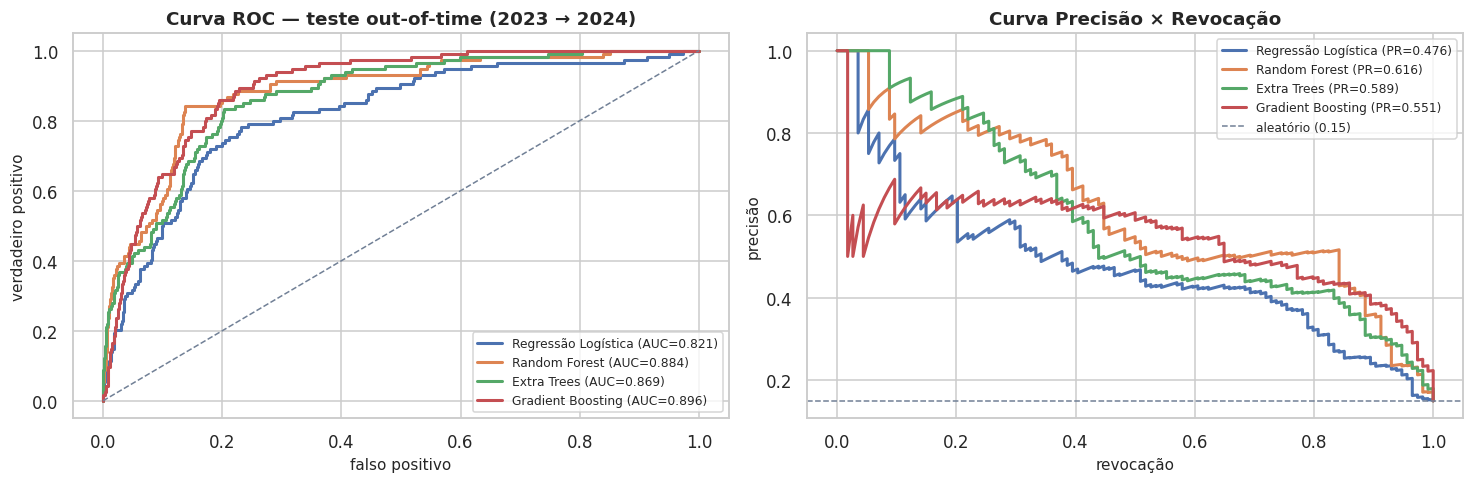

In [48]:
fig, eixos = plt.subplots(1, 2, figsize=(13.5, 4.5))

for nome, prob in probabilidades.items():
    if nome.startswith("Baseline"):
        continue
    fpr, tpr, _ = roc_curve(y[eh_teste], prob)
    eixos[0].plot(fpr, tpr, lw=2,
                  label=f"{nome} (AUC={roc_auc_score(y[eh_teste], prob):.3f})")
    precisao, revocacao, _ = precision_recall_curve(y[eh_teste], prob)
    eixos[1].plot(revocacao, precisao, lw=2,
                  label=f"{nome} (PR={average_precision_score(y[eh_teste], prob):.3f})")

eixos[0].plot([0, 1], [0, 1], "--", color=COR["neutro"], lw=1)
eixos[0].set_title("Curva ROC — teste out-of-time (2023 → 2024)")
eixos[0].set_xlabel("falso positivo")
eixos[0].set_ylabel("verdadeiro positivo")
eixos[0].legend(fontsize=8, loc="lower right")

eixos[1].axhline(y[eh_teste].mean(), ls="--", color=COR["neutro"], lw=1,
                 label=f"aleatório ({y[eh_teste].mean():.2f})")
eixos[1].set_title("Curva Precisão × Revocação")
eixos[1].set_xlabel("revocação")
eixos[1].set_ylabel("precisão")
eixos[1].legend(fontsize=8)

plt.tight_layout()
plt.show()

### Escolha do modelo final

O **Random Forest** é o escolhido. Não é o melhor em AUC — o Gradient Boosting ordena um
pouco melhor (0,896 contra 0,884) — mas ganha na métrica que mais importa aqui: a
**PR-AUC no teste é 0,616 contra 0,551**, ou seja, acerta bastante mais na classe rara,
que é a que a associação quer encontrar. Em Brier os dois empatam na prática (0,100 e
0,101), então a calibração não desempata.

O Extra Trees tem a melhor PR-AUC na validação cruzada (0,578), mas cai no teste
out-of-time e tem Brier bem pior (0,142) — probabilidades menos confiáveis. A regressão
logística fica claramente atrás: a relação entre indicadores e risco não é linear, como já
se via na taxa de risco por nível de defasagem.

Vale registrar a incerteza: o desvio padrão da AUC na validação cruzada é de 0,04 a 0,08
dependendo do modelo. Com 600 pares de treino e 98 casos positivos, diferenças pequenas
entre modelos não são conclusivas.

In [49]:
modelo_final = Pipeline([
    ("pre", montar_preprocessador()),
    ("clf", RandomForestClassifier(n_estimators=500, min_samples_leaf=5,
                                   class_weight="balanced", random_state=SEMENTE, n_jobs=-1)),
])
modelo_final.fit(X[eh_treino], y[eh_treino])

prob_teste = modelo_final.predict_proba(X[eh_teste])[:, 1]
y_teste = y[eh_teste].values

print(f"AUC     : {roc_auc_score(y_teste, prob_teste):.3f}")
print(f"PR-AUC  : {average_precision_score(y_teste, prob_teste):.3f} "
      f"(aleatório = {y_teste.mean():.3f})")
print(f"Brier   : {brier_score_loss(y_teste, prob_teste):.4f}")

AUC     : 0.884
PR-AUC  : 0.616 (aleatório = 0.149)
Brier   : 0.1001


## 4.5 O que o modelo aprendeu

Importância por permutação, medida no conjunto de teste — mede a queda real de desempenho
quando a variável é embaralhada, e não sofre o viés de cardinalidade da importância
nativa de árvores.

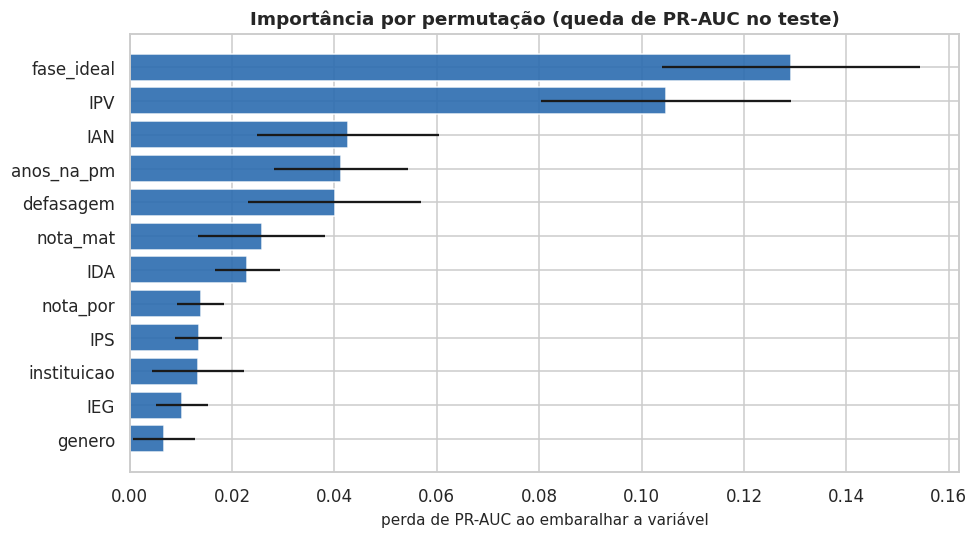

,variavel,importancia,desvio
0,fase_ideal,0.129,0.025
1,IPV,0.105,0.024
2,IAN,0.043,0.018
3,anos_na_pm,0.041,0.013
4,defasagem,0.040,0.017
5,nota_mat,0.026,0.012
6,IDA,0.023,0.006
7,nota_por,0.014,0.005
8,IPS,0.013,0.005
9,instituicao,0.013,0.009


In [50]:
from sklearn.inspection import permutation_importance

perm = permutation_importance(
    modelo_final, X[eh_teste], y_teste,
    scoring="average_precision", n_repeats=15, random_state=SEMENTE, n_jobs=-1,
)
importancia = (
    pd.DataFrame({"variavel": X.columns, "importancia": perm.importances_mean,
                  "desvio": perm.importances_std})
    .sort_values("importancia", ascending=False)
)

fig, eixo = plt.subplots(figsize=(9, 5))
principais = importancia.head(12).iloc[::-1]
eixo.barh(principais["variavel"], principais["importancia"],
          xerr=principais["desvio"], color=COR["principal"], alpha=0.9)
eixo.set_title("Importância por permutação (queda de PR-AUC no teste)")
eixo.set_xlabel("perda de PR-AUC ao embaralhar a variável")
plt.tight_layout()
plt.show()

display(importancia.head(10).round(4).reset_index(drop=True))

**Leitura.** O modelo apoia-se em três blocos, nesta ordem:

1. **Posição estrutural** — `fase_ideal` é de longe a variável mais forte (0,129 de perda
   de PR-AUC ao ser embaralhada). Ela captura o teto discutido em 4.2: o risco depende
   sobretudo de quanto o aluno ainda tem a perder.
2. **Comportamento** — `IPV` vem em segundo (0,105), à frente de todos os demais
   indicadores. É a confirmação, agora em contexto preditivo, da resposta à Pergunta 7:
   ponto de virada é o sinal comportamental mais informativo da base.
3. **Trajetória e desempenho** — `IAN`, `anos_na_pm`, `defasagem`, `nota_mat` e `IDA`
   formam um bloco de contribuições menores e semelhantes entre si.

Autoavaliação e indicadores psicossociais praticamente não contribuem — coerente com as
Perguntas 4 e 5, onde já se mostraram fracos. A nota de matemática aparece à frente das
outras disciplinas, o que a torna o melhor sinal isolado de desempenho para antecipar
defasagem.

## 4.6 Calibração e escolha do ponto de corte

O modelo entrega probabilidade. Para virar ação é preciso um corte, e o corte certo
depende da **capacidade de atendimento** da associação, não de um valor padrão como 0,5.

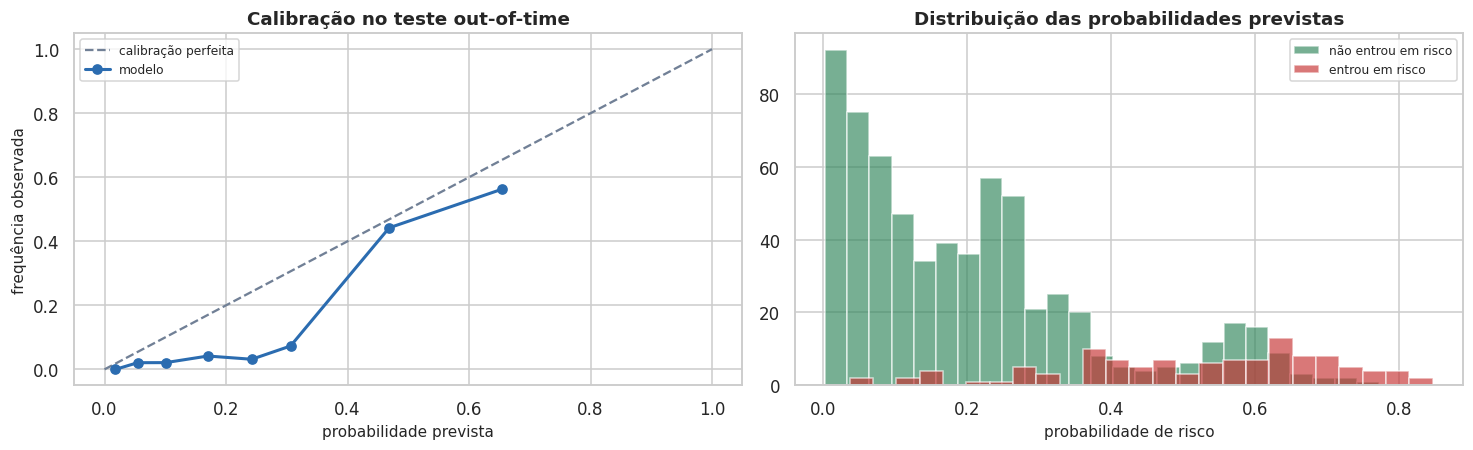

In [51]:
from sklearn.calibration import calibration_curve

fig, eixos = plt.subplots(1, 2, figsize=(13.5, 4.2))

fracao, media_prevista = calibration_curve(y_teste, prob_teste, n_bins=8, strategy="quantile")
eixos[0].plot([0, 1], [0, 1], "--", color=COR["neutro"], label="calibração perfeita")
eixos[0].plot(media_prevista, fracao, "o-", color=COR["principal"], lw=2, label="modelo")
eixos[0].set_title("Calibração no teste out-of-time")
eixos[0].set_xlabel("probabilidade prevista")
eixos[0].set_ylabel("frequência observada")
eixos[0].legend(fontsize=8)

eixos[1].hist(prob_teste[y_teste == 0], bins=25, alpha=0.65, color=COR["ok"],
              label="não entrou em risco")
eixos[1].hist(prob_teste[y_teste == 1], bins=25, alpha=0.65, color=COR["alerta"],
              label="entrou em risco")
eixos[1].set_title("Distribuição das probabilidades previstas")
eixos[1].set_xlabel("probabilidade de risco")
eixos[1].legend(fontsize=8)

plt.tight_layout()
plt.show()

,capacidade,alunos_priorizados,corte,precisao,revocacao,casos_capturados,ganho_sobre_aleatorio
0,top 5%,38,0.659,0.816,0.272,31,5.474
1,top 10%,76,0.598,0.632,0.421,48,4.238
2,top 15%,114,0.551,0.518,0.518,59,3.473
3,top 20%,153,0.436,0.497,0.667,76,3.333
4,top 25%,191,0.362,0.503,0.842,96,3.373
5,top 30%,229,0.315,0.428,0.860,98,2.872
6,top 40%,306,0.254,0.340,0.912,104,2.281


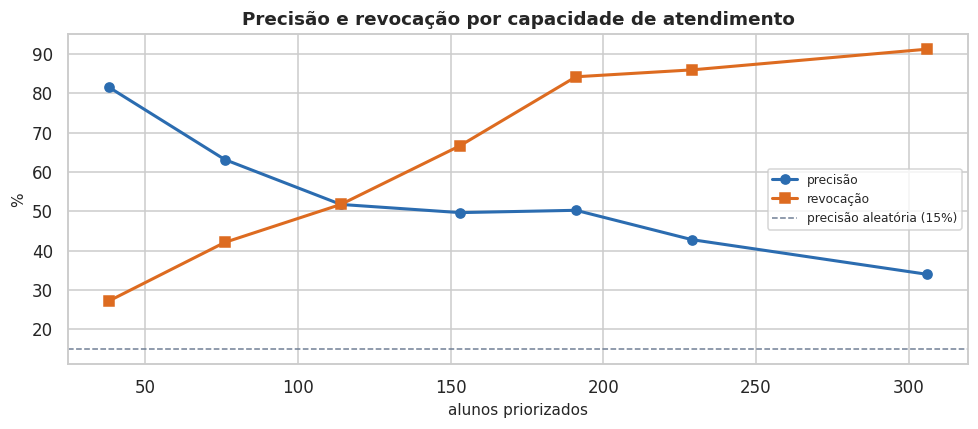

In [52]:
# quantos alunos a associação consegue acompanhar de perto?
ordenados = np.argsort(-prob_teste)
linhas = []
for capacidade in [0.05, 0.10, 0.15, 0.20, 0.25, 0.30, 0.40]:
    quantidade = int(len(prob_teste) * capacidade)
    selecionados = ordenados[:quantidade]
    linhas.append({
        "capacidade": f"top {capacidade:.0%}",
        "alunos_priorizados": quantidade,
        "corte": prob_teste[selecionados].min(),
        "precisao": y_teste[selecionados].mean(),
        "revocacao": y_teste[selecionados].sum() / y_teste.sum(),
        "casos_capturados": int(y_teste[selecionados].sum()),
        "ganho_sobre_aleatorio": y_teste[selecionados].mean() / y_teste.mean(),
    })

capacidade_df = pd.DataFrame(linhas)
display(capacidade_df.round(3))

fig, eixo = plt.subplots(figsize=(9, 4))
eixo.plot(capacidade_df["alunos_priorizados"], capacidade_df["precisao"] * 100,
          "o-", color=COR["principal"], lw=2, label="precisão")
eixo.plot(capacidade_df["alunos_priorizados"], capacidade_df["revocacao"] * 100,
          "s-", color=COR["atencao"], lw=2, label="revocação")
eixo.axhline(y_teste.mean() * 100, ls="--", color=COR["neutro"], lw=1,
             label=f"precisão aleatória ({y_teste.mean():.0%})")
eixo.set_title("Precisão e revocação por capacidade de atendimento")
eixo.set_xlabel("alunos priorizados")
eixo.set_ylabel("%")
eixo.legend(fontsize=8)
plt.tight_layout()
plt.show()

**Como ler.** Priorizando os **25% de maior risco** — 191 alunos —, o modelo captura
**84% de todos os que de fato entrariam em defasagem**, com metade dos priorizados sendo
casos reais. Isso é mais de **três vezes** melhor que escolher ao acaso.

Se a capacidade for menor, o top 10% entrega precisão de 63%: de cada 10 alunos chamados,
6 realmente estavam a caminho da defasagem.

O corte não é uma propriedade do modelo, é uma decisão de gestão. Por isso a
recomendação é entregar a probabilidade no Streamlit e deixar o corte configurável.

Corte adotado: 0.362

              precision    recall  f1-score   support

   sem risco      0.969     0.854     0.908       651
    em risco      0.503     0.842     0.630       114

    accuracy                          0.852       765
   macro avg      0.736     0.848     0.769       765
weighted avg      0.899     0.852     0.866       765



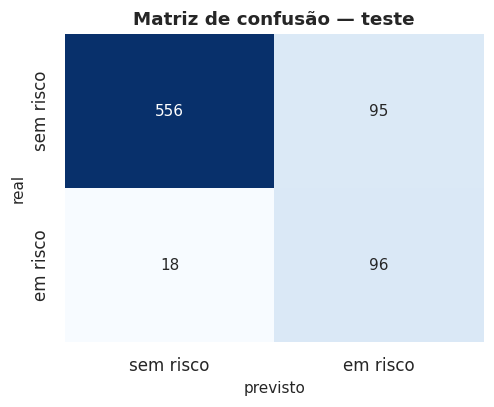

In [53]:
CORTE = float(capacidade_df.loc[capacidade_df["capacidade"] == "top 25%", "corte"].iloc[0])
previsto = (prob_teste >= CORTE).astype(int)

print(f"Corte adotado: {CORTE:.3f}\n")
print(classification_report(y_teste, previsto,
                            target_names=["sem risco", "em risco"], digits=3))

matriz_confusao = confusion_matrix(y_teste, previsto)
fig, eixo = plt.subplots(figsize=(4.6, 3.8))
sns.heatmap(matriz_confusao, annot=True, fmt="d", cmap="Blues", cbar=False, ax=eixo,
            xticklabels=["sem risco", "em risco"], yticklabels=["sem risco", "em risco"])
eixo.set_title("Matriz de confusão — teste")
eixo.set_xlabel("previsto")
eixo.set_ylabel("real")
plt.tight_layout()
plt.show()

## 4.7 Matriz de priorização

O modelo responde "quem vai piorar". O IAN responde "quem já está mal". Cruzar os dois
resolve a limitação apontada em 4.2 e produz um instrumento que a equipe usa direto.

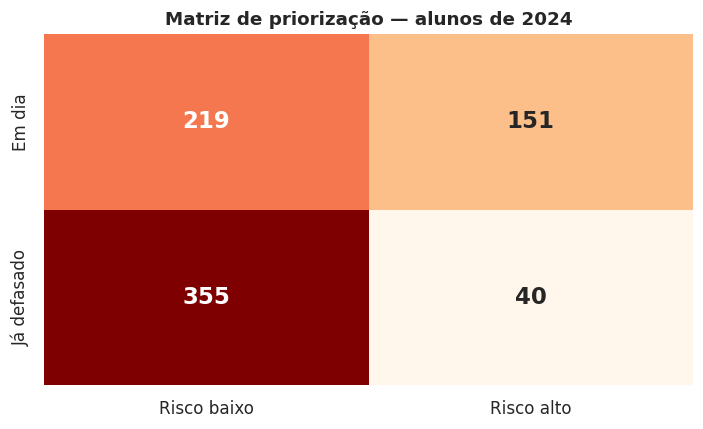

risco_alto,Risco baixo,Risco alto
ja_defasado,,
Em dia,219,151
Já defasado,355,40


In [54]:
priorizacao = transicoes[eh_teste].copy()
priorizacao["probabilidade"] = prob_teste
priorizacao["risco_alto"] = priorizacao["probabilidade"] >= CORTE
priorizacao["ja_defasado"] = priorizacao["defasagem"] < 0

quadrantes = pd.crosstab(
    priorizacao["ja_defasado"].map({True: "Já defasado", False: "Em dia"}),
    priorizacao["risco_alto"].map({True: "Risco alto", False: "Risco baixo"}),
)
quadrantes = quadrantes.reindex(index=["Em dia", "Já defasado"],
                                columns=["Risco baixo", "Risco alto"])

fig, eixo = plt.subplots(figsize=(6.5, 4))
sns.heatmap(quadrantes, annot=True, fmt="d", cmap="OrRd", cbar=False, ax=eixo,
            annot_kws={"size": 15, "weight": "bold"})
eixo.set_title("Matriz de priorização — alunos de 2024")
eixo.set_xlabel("")
eixo.set_ylabel("")
plt.tight_layout()
plt.show()

display(quadrantes)

| Quadrante | Leitura | Ação sugerida |
|---|---|---|
| Em dia · risco alto | prestes a perder o passo | **prioridade 1** — é aqui que o modelo agrega valor que nenhum relatório dá |
| Já defasado · risco alto | atrasado e piorando | prioridade 1 — intervenção intensiva |
| Já defasado · risco baixo | atrasado mas estável | reforço continuado, sem urgência |
| Em dia · risco baixo | trajetória saudável | acompanhamento padrão |

## 4.8 Salvando o modelo para o Streamlit

In [55]:
import joblib

PASTA_MODELOS = PASTA_BASE.parent / "modelos"
PASTA_MODELOS.mkdir(exist_ok=True)

artefato = {
    "modelo": modelo_final,
    "variaveis_numericas": VARIAVEIS_NUMERICAS,
    "variaveis_categoricas": VARIAVEIS_CATEGORICAS,
    "corte_sugerido": CORTE,
    "treinado_em": "transições 2022 → 2023",
    "validado_em": "transições 2023 → 2024",
    "metricas_teste": {
        "auc": float(roc_auc_score(y_teste, prob_teste)),
        "pr_auc": float(average_precision_score(y_teste, prob_teste)),
        "brier": float(brier_score_loss(y_teste, prob_teste)),
        "prevalencia": float(y_teste.mean()),
    },
    "definicao_alvo": "entrar em defasagem ou aprofundar a defasagem existente no ano seguinte",
}

caminho_modelo = PASTA_MODELOS / "modelo_risco_defasagem.joblib"
joblib.dump(artefato, caminho_modelo)
print(f"Modelo salvo em {caminho_modelo}")

# painel consolidado, insumo do app
PASTA_SAIDA = PASTA_BASE.parent / "dados_processados"
PASTA_SAIDA.mkdir(exist_ok=True)
painel.to_csv(PASTA_SAIDA / "painel_pede_2022_2024.csv", sep=";", decimal=",",
              index=False, encoding="utf-8-sig")
transicoes.to_csv(PASTA_SAIDA / "base_modelagem.csv", sep=";", decimal=",",
                  index=False, encoding="utf-8-sig")
print(f"Painel e base de modelagem salvos em {PASTA_SAIDA}")

Modelo salvo em /home/claude/nb2/modelos/modelo_risco_defasagem.joblib
Painel e base de modelagem salvos em /home/claude/nb2/dados_processados


---
# Parte 5 — Conclusões

## O que os dados dizem

**O programa melhora os indicadores agregados — mas a melhora é composicional.** O INDE
médio subiu de 7,04 (2022) para 7,40 (2024) e a defasagem caiu de 70% para 46% dos alunos.
Entre os 434 alunos acompanhados nos três anos, porém, a variação média do INDE é zero. Os
alunos com pior desempenho são justamente os que não retornam (INDE 6,51 contra 7,26 dos
que ficam), e os ingressantes chegam acima da média dos veteranos. **Retenção é o tema que
os dados apontam com mais força.**

**Onde o programa comprovadamente entrega é na adequação de nível.** A defasagem cai de
forma consistente com o tempo de casa — de 60% no primeiro ano para 29% no oitavo — mesmo
sem elevação do INDE. Recolocar o aluno na fase certa é o resultado mais sólido da série.

**Engajamento é a alavanca.** O IEG é o indicador que mais se conecta com aprendizagem
(r = 0,54) e ponto de virada (r = 0,54), e é o único claramente acionável pela equipe.
Aprendizagem e ponto de virada são consequências; engajamento é causa.

**A autoavaliação não acompanha a realidade.** Correlação de 0,10 a 0,22 com o desempenho
real. 30% dos registros são de alunos que se superestimam em mais de 3 pontos, com o pior
IDA da base — não pedem ajuda e por isso não aparecem nos encaminhamentos.

**IPS e IPP medem outra coisa.** Nenhum dos dois antecipa queda de desempenho nem confirma
a defasagem do IAN. Não é defeito conceitual: são dimensões distintas. Mas ambos têm
problemas de medição — o IPP quase não varia entre alunos e o IPS teve uma oscilação
inexplicada em 2023.

## O modelo

Random Forest treinado nas transições 2022→2023 e validado out-of-time em 2023→2024:
**AUC 0,88 e PR-AUC 0,62** contra uma prevalência de 0,15. Priorizando os 25% de maior
risco — 191 alunos —, captura **84% dos que de fato entram em defasagem**, com precisão de
50%: mais de três vezes melhor que escolher ao acaso.

O modelo é um **alerta precoce, não um ranking de gravidade**. Deve ser lido junto com o
IAN, na matriz de priorização da seção 4.7.

## Recomendações para a Passos Mágicos

1. **Investigar a evasão seletiva.** É o achado de maior impacto: os alunos que saem são
   os de pior desempenho. Entender por que saem vale mais, hoje, do que qualquer ajuste
   pedagógico.
2. **Rodar o modelo no fim de cada ciclo** e usar a matriz de priorização para montar a
   lista de acompanhamento do ano seguinte.
3. **Busca ativa no grupo "engajado mas travado"** — 22% da base, adesão garantida, falta
   método.
4. **Busca ativa no grupo que se superestima** — 30% dos registros, pior desempenho da
   base, e que por definição não vai pedir ajuda.
5. **Corrigir a governança dos dados**: o dicionário está desatualizado nas faixas de
   Pedra, `Atingiu PV` e `Rec Psicologia` deixaram de ser preenchidos em 2023/2024, o
   `Ano ingresso` foi reescrito na base de 2024 e o IPS de 2023 precisa de conferência.

## Limitações honestas

- O treino tem 600 pares e 98 casos positivos. É pouco, e as métricas têm incerteza real —
  o desvio padrão da AUC na validação cruzada chega a 0,08.
- Sem `IPP` no modelo, porque a coluna não existe em 2022.
- O modelo prevê **piora**, não gravidade. Alunos já severamente defasados recebem
  probabilidade baixa por efeito de teto, e por isso o resultado só deve ser lido junto
  com o IAN.
- A nota de inglês só existe para um terço dos alunos.
- Sem `Atingiu PV` em 2023/2024, não foi possível modelar o Ponto de Virada diretamente.

## Próximos passos

- Aplicação Streamlit consumindo `modelos/modelo_risco_defasagem.joblib`.
- Apresentação gerencial com o storytelling desta análise.
- Vídeo de até 5 minutos.
